# F_cross_correlation.ipynb

## Purpose
Analyzes spike-train temporal structure using auto-correlations and cross-correlations. Computes pairwise cross-correlations between simultaneously recorded neurons, applies PCA to summarize their structure, and tests whether functional connectivity patterns vary systematically along the spatial axes that organize behavioral encoding.

## Prerequisites
- `combined_unit_tbl.pkl` — quality-controlled unit table (`manuscript_fig_prep_dir/combined_unit_tbl/`)
- `basic_ephys.json` — QC thresholds (`code/beh_ephys_analysis/session_combine/metrics/`)
- Per-session auto-correlation data via `load_auto_corr(session, "curated")`
- Per-session cross-correlation data via `load_cross_corr(session, "curated")`
- Per-session unit tables and spike times via `get_unit_tbl()` and `get_session_tbl()`
- Per-session lick event data via `load_licks()`
- Raw recording files (HDF5) via `session_dirs(session)["raw_rec"]`
- `spatial_dependence_results_beh_all.pkl` — behavioral-encoding spatial axes (`manuscript_fig_dir/F_ephys_beh_action&outcome/`)
- `spatial_dependence_results_pca_waveform_all.pkl` — waveform-PCA spatial axes (`manuscript_fig_dir/F_waveform_space/`)

## Figure Panels
- **Figure4e**: Example extracellular spiking (raw trace + spike raster) around two trials
- **FigureE12r_left**: Raster plot of three simultaneously recorded neurons with correlated spike rates
- **FigureE12r_mid**: Smoothed firing-rate traces for the same simultaneously recorded neurons
- **FigureE12r_right**: Cross-correlograms between those neurons during the whole experiment and spontaneous spiking
- **FigureE12s**: Example cross-correlograms across all unit pairs sorted by cross-correlation PC1
- **FigureE12t**: Spatial analysis of cross-correlogram PC1 versus task-response behavioral encoding axes (scatter)

## Imports

Sets up the Python path relative to this notebook's location so utilities can be imported from any checkout. Loads analysis utilities for behavior, electrophysiology, plotting, CCF coordinate mapping, and SpikeInterface for raw recording access.

In [2]:
import os

# Resolve code/beh_ephys_analysis (the folder containing `utils`) relative to this
# file's location, so imports work no matter where the repo is checked out.
import pathlib
import sys

# Resolve code/beh_ephys_analysis (the folder containing `utils`) relative to this
# file's location, so imports work no matter where the repo is checked out.
try:
    _here = pathlib.Path(__file__).resolve().parent          # script mode
except NameError:
    try:
        _here = pathlib.Path(__vsc_ipynb_file__).resolve().parent  # VS Code notebook
    except NameError:
        _here = pathlib.Path(os.getcwd())                    # other Jupyter fallback

_beh_ephys_root = str((_here / '../..').resolve())
if _beh_ephys_root not in sys.path:
    sys.path.insert(0, _beh_ephys_root)
import json
import pickle

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import spikeinterface.preprocessing as spre
from matplotlib.colors import LinearSegmentedColormap
from scipy.stats import rankdata, zscore
from utils.beh_functions import get_session_tbl, get_unit_tbl, session_dirs
from utils.capsule_migration import capsule_directories
from utils.combine_tools import apply_qc, spatial_dependence_summary, to_str_intlike
from utils.ephys_functions import get_spike_matrix, load_auto_corr, load_cross_corr
from utils.hdf5_extractor import read_hdf5
from utils.lick_utils import load_licks

capsule_dirs = capsule_directories()
%matplotlib inline
import itertools

from joblib import Parallel, delayed
from sklearn.decomposition import PCA
from statsmodels.stats.multitest import multipletests
from utils.capsule_migration import CAPSULE_ROOT
from utils.panel_utils import columns_to_df, save_panel_csv, save_panels


## Load Unit Table and Apply Quality Control

Load `combined_unit_tbl.pkl` and the `basic_ephys` QC criteria, then filter to retain only well-isolated units. Sets up the output directory for this figure panel.

Applying bounds for isi_violations: [0.0, 0.2]
 - isi_violations: 15278 -> 7875 units passed
Applying items for qc_pass: [True]
 - qc_pass: 7875 -> 5399 units passed
Applying bounds for peak: [-1000, 500]
 - peak: 5399 -> 5368 units passed
Applying conditional bounds for y_loc
 - y_loc: 5368 -> 3770 units passed
Applying opto conditions: ['p_max', 'eu', 'corr', 'tag_loc', 'lat_max_p', 'p_mean', 'sig_counts']
Number of opto rows after filtering: 365
Number of non-opto rows after filtering: 3770


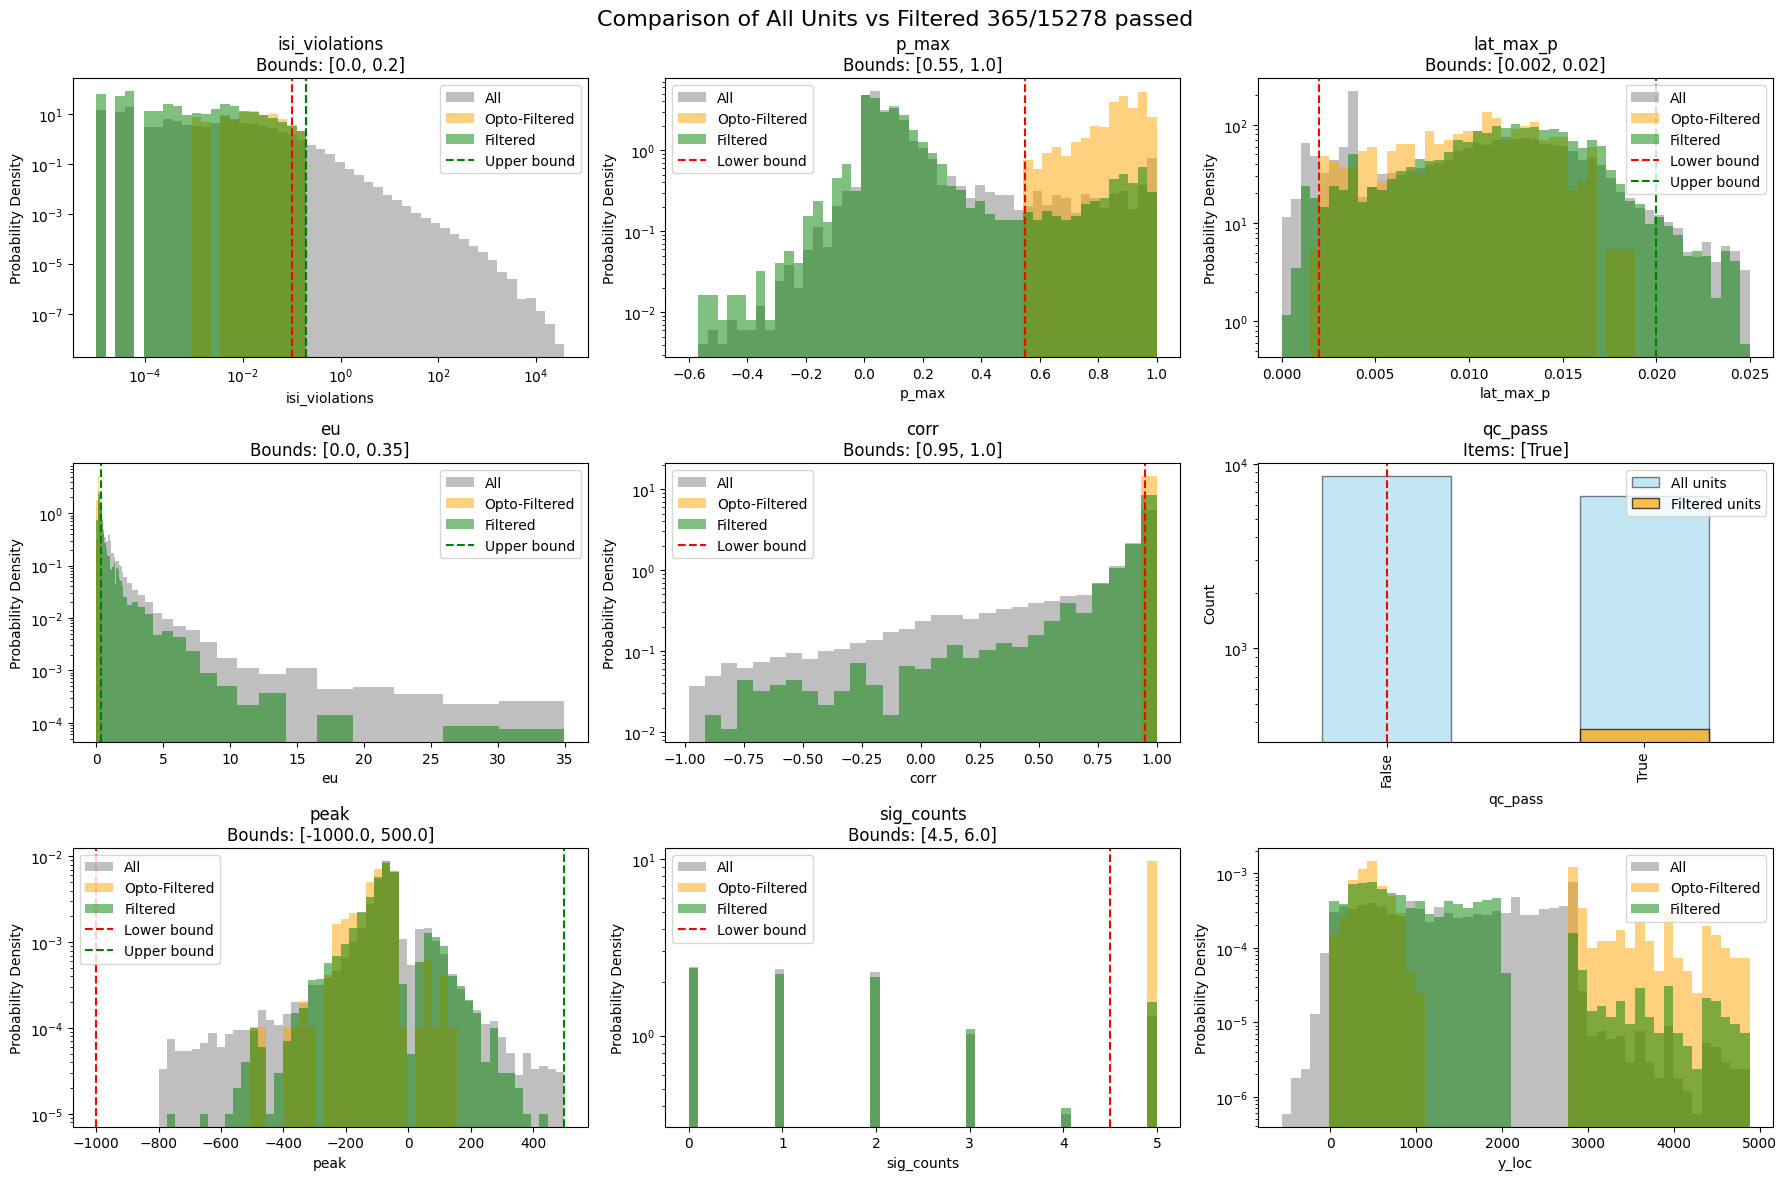

In [3]:
criteria_name = 'basic_ephys'
target_folder = os.path.join(capsule_dirs["manuscript_fig_dir"], 'F_cross_corr')
if not os.path.exists(target_folder):
    os.makedirs(target_folder)
with open(os.path.join(capsule_dirs["manuscript_fig_prep_dir"], 'combined_unit_tbl', 'combined_unit_tbl.pkl'), 'rb') as f:
    combined_tagged_units = pickle.load(f)

with open(os.path.join(CAPSULE_ROOT + '/code/beh_ephys_analysis/session_combine/metrics', f'{criteria_name}.json'), 'r') as f:
    constraints = json.load(f)

combined_tagged_units_filtered, combined_tagged_units, fig, axes = apply_qc(combined_tagged_units, constraints)

In [4]:
combined_tagged_units_filtered['unit_id'] = combined_tagged_units_filtered['unit'].apply(lambda x: to_str_intlike(x))

## Load Auto-Correlation Data for All Units

Standardize unit IDs, then load pre-computed auto-correlation traces (long and short no-go windows) for every QC-passing unit in parallel. Units with recording durations shorter than 1000 s are dropped from subsequent analyses.

In [ ]:
# loop trough all unit and load auto corr

def _fetch_one_autocorr(session, unit_id, data_type="curated"):
    auto_corr = load_auto_corr(session, data_type)
    auto_unit = auto_corr.load_unit(unit_id)

    if auto_unit is None:
        return None, None, np.nan

    long_ = auto_unit.get("auto_corr_long_nogo", None)
    short_ = auto_unit.get("auto_corr_short_nogo", None)

    start = auto_unit.get("start", np.nan)
    end = auto_unit.get("end", np.nan)
    length = (end - start) if (np.isfinite(start) and np.isfinite(end)) else np.nan

    return long_, short_, length

# prepare lightweight inputs
sessions = combined_tagged_units_filtered["session"].to_numpy()
unit_ids = combined_tagged_units_filtered["unit"].to_numpy()

results = Parallel(n_jobs=-1, backend="loky", verbose=10)(
    delayed(_fetch_one_autocorr)(s, u, "curated") for s, u in zip(sessions, unit_ids)
)

auto_corr_list_long, auto_corr_list_short, lengths = map(list, zip(*results))

# assign back
combined_tagged_units_filtered["auto_corr_long_nogo"] = auto_corr_list_long
combined_tagged_units_filtered["auto_corr_short_nogo"] = auto_corr_list_short
combined_tagged_units_filtered["length"] = lengths

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:    8.9s
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:    9.4s
[Parallel(n_jobs=-1)]: Done  29 tasks      | elapsed:   13.8s
[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:   14.0s
[Parallel(n_jobs=-1)]: Done  53 tasks      | elapsed:   18.8s
[Parallel(n_jobs=-1)]: Done  66 tasks      | elapsed:   23.4s
[Parallel(n_jobs=-1)]: Done  81 tasks      | elapsed:   28.3s
[Parallel(n_jobs=-1)]: Done  96 tasks      | elapsed:   28.8s
[Parallel(n_jobs=-1)]: Done 113 tasks      | elapsed:   33.8s
[Parallel(n_jobs=-1)]: Done 130 tasks      | elapsed:   38.3s
[Parallel(n_jobs=-1)]: Done 149 tasks      | elapsed:   43.0s
[Parallel(n_jobs=-1)]: Done 168 tasks      | elapsed:   47.6s
[Parallel(n_jobs=-1)]: Done 189 tasks      | elapsed:   54.7s
[Parallel(n_jobs=-1)]: Done 210 tasks      | elapsed:  1.1min
[Parallel(n_jobs=-1)]: Done 233 tasks      | elapsed:  

In [6]:
# filter out units with recording length < 1000 seconds
filter = combined_tagged_units_filtered['length']>=1000

In [7]:
combined_tagged_units_filtered = combined_tagged_units_filtered[filter].reset_index(drop=True)

## Build Unit-Pair List and Load Cross-Correlation Data

Enumerate all unique within-session unit pairs, then load the pre-computed pairwise cross-correlation traces (long and short timescales, no-go condition) in parallel. Anatomical coordinates (probe y_loc and CCF x/y/z) for both units in each pair are merged in for downstream spatial analyses.

In [8]:
# loop through sessions and find a table of session - unit_1 - unit_2 dataframe to load 
session_unit_pairs = []
for session in combined_tagged_units_filtered['session'].unique():
    session_df = combined_tagged_units_filtered[combined_tagged_units_filtered['session'] == session]
    unit_ids = session_df['unit'].to_list()
    for i in range(len(unit_ids)):
        for j in range(i+1, len(unit_ids)):
            session_unit_pairs.append((session, (unit_ids[i], unit_ids[j])))
session_unit_pairs_df = pd.DataFrame(session_unit_pairs, columns=['session', 'unit_pair'])

## Summary: number of pairs per session

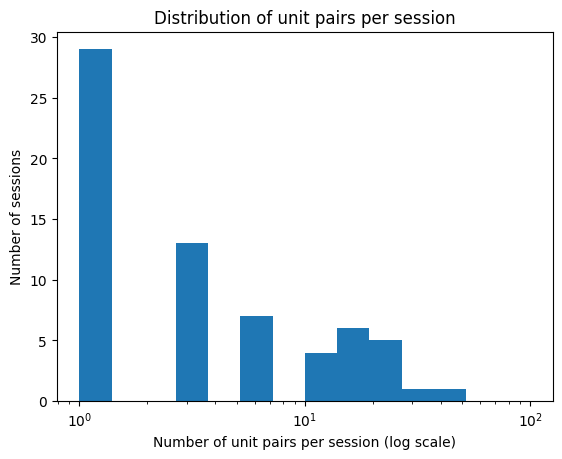

In [9]:
# set up bin edges proper for log scale
bin_edges = np.logspace(0, 2, num=15)
# plot histogram of number of unit pairs per session
plt.hist(session_unit_pairs_df.groupby("session")["unit_pair"].count(), bins = bin_edges)
# change x axis to log scale
plt.xscale("log")
plt.xlabel("Number of unit pairs per session (log scale)")
plt.ylabel("Number of sessions")
plt.title("Distribution of unit pairs per session")
plt.savefig(os.path.join(target_folder, 'unit_pairs_per_session_histogram.pdf'))

## Load Cross-Correlation Data and Merge Spatial Information

Load pre-computed cross-correlation data for all unit pairs using parallel processing for efficiency. Merge this data with anatomical location information (probe depth y_loc and CCF coordinates x/y/z) for both units in each pair, enabling spatial analysis of functional connectivity patterns.

In [10]:
data_type = "curated"
def _fetch_one_crosscorr(session, unit_pair, data_type):
    cross_corr = load_cross_corr(session, data_type)
    if cross_corr is None:
        return None, session

    pair_cross = cross_corr.load_units(unit_pair[0], unit_pair[1])
    if pair_cross is None:
        return None, session

    pair_cross = pair_cross.copy()
    pair_cross["length"] = pair_cross["end"] - pair_cross["start"]
    return pair_cross, session

results = Parallel(n_jobs=-1, backend="loky", verbose=10)(
    delayed(_fetch_one_crosscorr)(row["session"], row["unit_pair"], data_type)
    for _, row in session_unit_pairs_df.iterrows()
)

cross_corr_list, session_list = map(list, zip(*results))

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:    0.8s
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:    0.9s
[Parallel(n_jobs=-1)]: Done  29 tasks      | elapsed:    1.5s
[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    1.7s
[Parallel(n_jobs=-1)]: Done  53 tasks      | elapsed:    2.0s
[Parallel(n_jobs=-1)]: Done  66 tasks      | elapsed:    2.2s
[Parallel(n_jobs=-1)]: Done  81 tasks      | elapsed:    2.5s
[Parallel(n_jobs=-1)]: Done  96 tasks      | elapsed:    3.0s
[Parallel(n_jobs=-1)]: Done 113 tasks      | elapsed:    3.3s
[Parallel(n_jobs=-1)]: Done 130 tasks      | elapsed:    3.6s
[Parallel(n_jobs=-1)]: Done 149 tasks      | elapsed:    4.4s
[Parallel(n_jobs=-1)]: Done 168 tasks      | elapsed:    5.0s
[Parallel(n_jobs=-1)]: Done 189 tasks      | elapsed:    5.4s
[Parallel(n_jobs=-1)]: Done 210 tasks      | elapsed:    5.7s
[Parallel(n_jobs=-1)]: Done 233 tasks      | elapsed:  

In [11]:
cross_corr_df = pd.DataFrame(cross_corr_list)
cross_corr_df["session"] = session_list

# find location of each neuron, unit 1 and unit 2, load both ccf locations and y_loc (estimated location along the probe)
cross_corr_df['unit_id'] = cross_corr_df['unit_1'].apply(lambda x: to_str_intlike(x))
combined_tagged_units_filtered['unit_id'] = combined_tagged_units_filtered['unit'].apply(lambda x: to_str_intlike(x))
cross_corr_df = cross_corr_df.merge(combined_tagged_units_filtered[['session', 'unit_id', 'y_loc', 'x_ccf', 'y_ccf', 'z_ccf']], on=['session', 'unit_id'], how='left')
# rename columns to unit 1
cross_corr_df = cross_corr_df.rename(columns={'y_loc': 'y_loc_1', 'x_ccf': 'x_ccf_1', 'y_ccf': 'y_ccf_1', 'z_ccf': 'z_ccf_1'})
cross_corr_df['unit_id'] = cross_corr_df['unit_2'].apply(lambda x: to_str_intlike(x))
cross_corr_df = cross_corr_df.merge(combined_tagged_units_filtered[['session', 'unit_id', 'y_loc', 'x_ccf', 'y_ccf', 'z_ccf']], on=['session', 'unit_id'], how='left')
# rename columns to unit 2
cross_corr_df = cross_corr_df.rename(columns={'y_loc': 'y_loc_2', 'x_ccf': 'x_ccf_2', 'y_ccf': 'y_ccf_2', 'z_ccf': 'z_ccf_2'})

In [12]:
print(f'Total unit pairs with cross-corr data: {len(cross_corr_df)}')

Total unit pairs with cross-corr data: 426


## Example Sessions Visualization
Visualize example sessions to illustrate neural activity patterns. For each unit, generate raster plots showing individual spike times and smoothed firing rate traces aligned to behavioral events. This provides context for understanding the temporal structure that cross-correlations will quantify.

### Example Session 1: Overlayed Firing Rate and Spike Raster

For the same example session, plot firing rate, spike rasters and behavioral events (go cues, licks, rewards) in a single overlay. This produces the multi-unit time-series view saved as FigureE12r_left and FigureE12r_mid.

['/root/capsule/scratch/results/manuscript/figures/F_cross_corr/FigureS15r_mid_example_session_go_cue_times_events.csv']

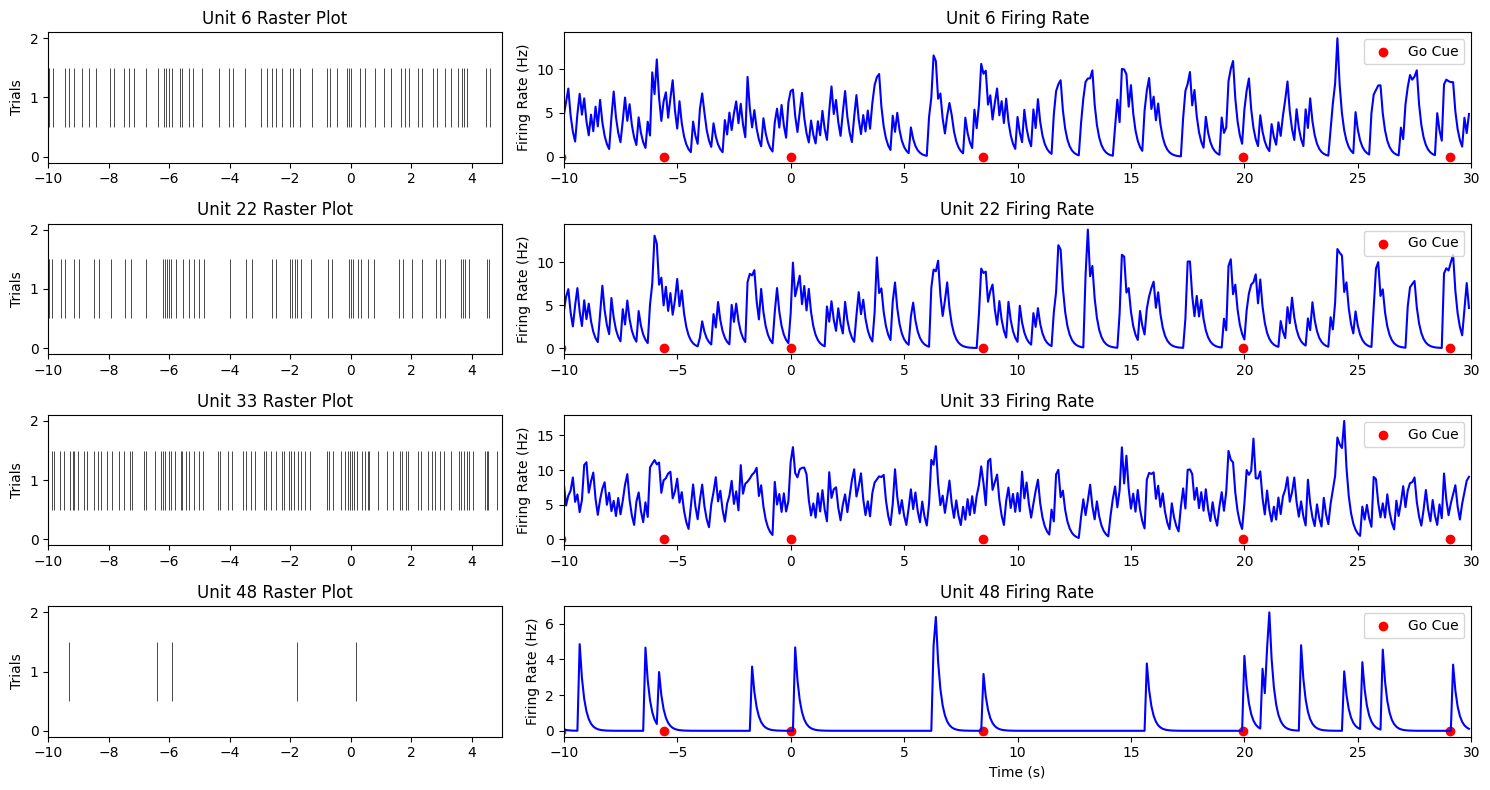

In [14]:
example_session = 'behavior_751004_2024-12-21_13-28-28'
unit_tbl = get_unit_tbl(example_session, data_type="curated")
unit_list = combined_tagged_units_filtered[combined_tagged_units_filtered['session'] == example_session]['unit'].to_list()
session_tbl = get_session_tbl(example_session)
start_time = session_tbl['goCue_start_time'].values[21]
pre_time = -10
post_time = 5

fig, axes = plt.subplots(len(unit_list), 2, figsize=(15, 2*len(unit_list)), width_ratios=[0.5, 1])
_rast_u = {}
_fr = {}
go_cue_times = session_tbl['goCue_start_time'].values

for i, unit_id in enumerate(unit_list):
    spike_times = unit_tbl[unit_tbl['unit_id'] == unit_id]['spike_times'].values[0]
    aligned_spikes = spike_times - start_time
    aligned_spikes = aligned_spikes[(aligned_spikes>=pre_time) & (aligned_spikes<=post_time)]
    _rast_u[str(unit_id)] = aligned_spikes
    # raster_plot
    axes[i, 0].eventplot(aligned_spikes, colors='black', linewidths=0.5)
    axes[i, 0].set_title(f'Unit {unit_id} Raster Plot')
    axes[i, 0].set_xlim([pre_time, post_time])
    axes[i, 0].set_ylabel('Trials')

    spike_mat, slide_time = get_spike_matrix(spike_times, np.array([start_time]), 
                                            pre_event=pre_time, post_event=30, stepSize=0.1,
                                            kernel=True, tau_rise=0.001, tau_decay=0.2)
    mean_firing_rate = np.mean(spike_mat, axis=0)
    _fr['time_s'] = np.asarray(slide_time); _fr[f'unit_{unit_id}'] = mean_firing_rate
    axes[i, 1].plot(slide_time, mean_firing_rate, color='blue')
    axes[i, 1].set_ylabel('Firing Rate (Hz)')
    axes[i, 1].scatter(go_cue_times - start_time, np.zeros_like(go_cue_times), color='red', label='Go Cue')
    axes[i, 1].set_title(f'Unit {unit_id} Firing Rate')
    axes[i, 1].set_xlim([pre_time, 30])
    axes[i, 1].legend()
plt.xlabel('Time (s)')
plt.tight_layout()
save_panels(fig, target_folder, f'example_session_{example_session}_raster_firingrate', ['FigureE12r_left', 'FigureE12r_mid'], exts=('pdf', 'svg'))
# ---- panel CSVs (rule 4 raster + rule 3 firing-rate; rule 9: r_left/r_mid share JSON desc -> save both under each) ----

save_panel_csv(columns_to_df(**_rast_u), target_folder, f'example_session_{example_session}_raster', ['FigureE12r_left'], plot_type='raster')
save_panel_csv(columns_to_df(**_fr), target_folder, f'example_session_{example_session}_raster_firingrate', ['FigureE12r_mid'], plot_type='firing_rate')
save_panel_csv(columns_to_df(**{'go_cue_times': go_cue_times - start_time}), target_folder, f'example_session_go_cue_times', ['FigureE12r_mid'], plot_type='events')
##FigureE12r_left##
##FigureE12r_mid##

### Example Session 1: Overlayed Firing Rate, Spike Raster and behavior events

For the same example session, plot firing rate, spike rasters and behavioral events (go cues, licks, rewards) in a single overlay. This produces the multi-unit time-series.

/tmp/ipykernel_2899883/2556958171.py:41: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[i].legend()


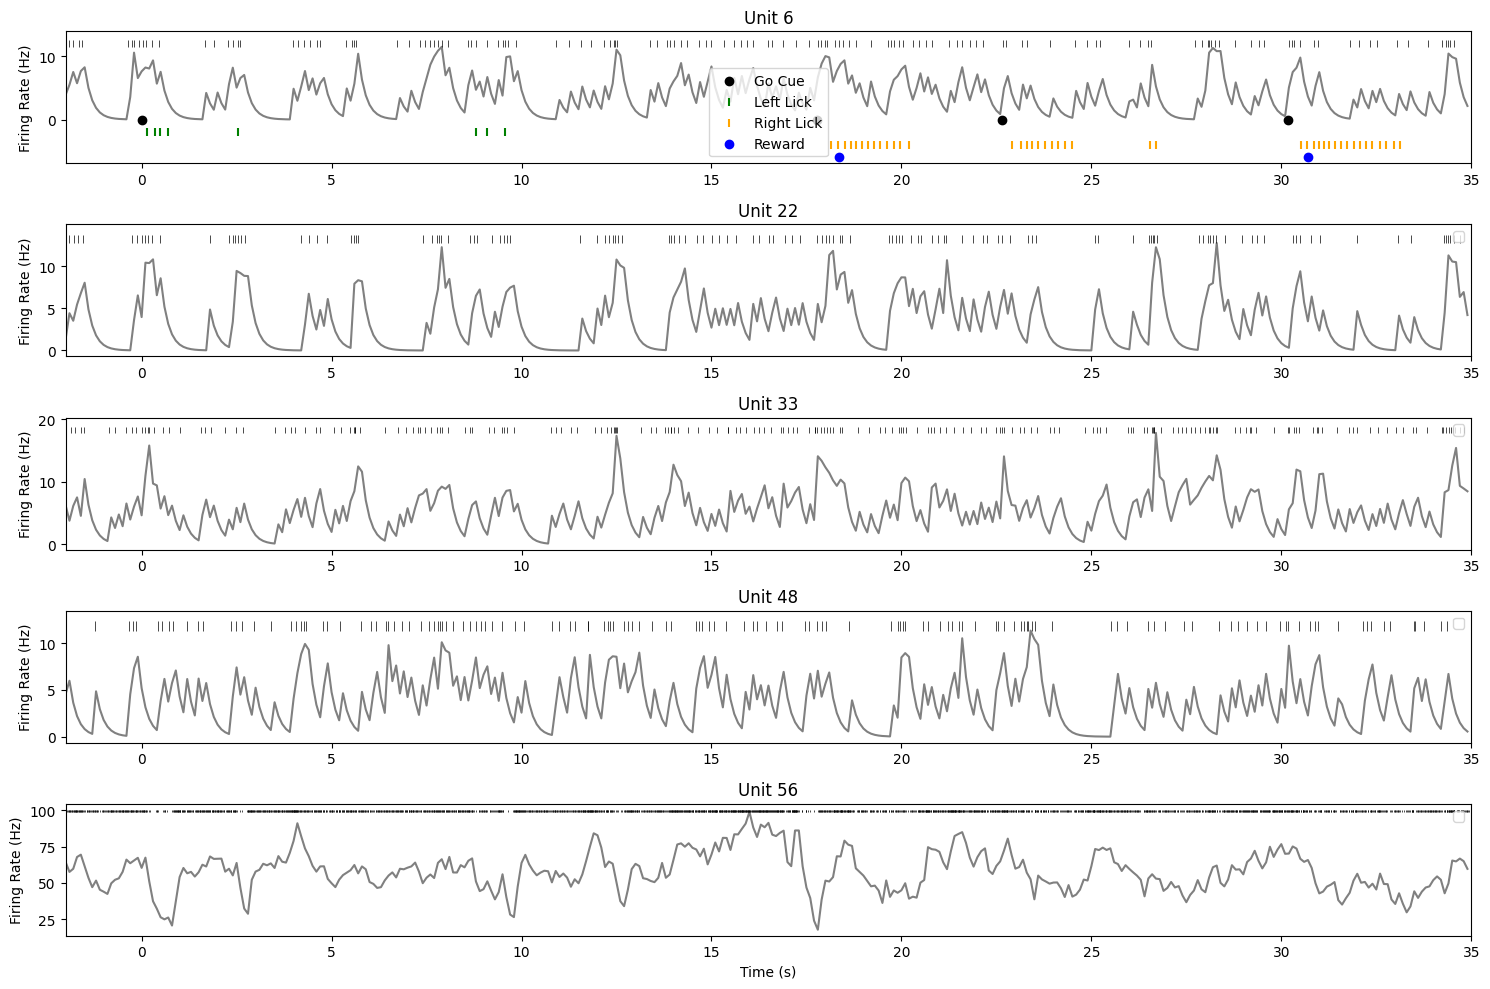

In [15]:
example_session = 'behavior_751004_2024-12-21_13-28-28'
licks = load_licks(example_session)
unit_tbl = get_unit_tbl(example_session, data_type="curated")
unit_list = combined_tagged_units_filtered[combined_tagged_units_filtered['session'] == example_session]['unit'].to_list()
unit_list.extend([56])  # add two more units for better visualization
session_tbl = get_session_tbl(example_session)
start_time = session_tbl['goCue_start_time'].values[171]
pre_time = -2
post_time = 35

trains_L = licks['lick_trains_L']['train_starts']
trains_R = licks['lick_trains_R']['train_starts']
aligned_L_licks = licks['licks_L_cleaned'] - start_time
aligned_R_licks = licks['licks_R_cleaned']  - start_time 

reward_times = session_tbl[session_tbl['rewarded_historyL'] | session_tbl['rewarded_historyR']]['reward_outcome_time'].values - start_time + 0.2

fig, axes = plt.subplots(len(unit_list), 1, figsize=(15, 2*len(unit_list)))
go_cue_times = session_tbl['goCue_start_time'].values

for i, unit_id in enumerate(unit_list):
    spike_times = unit_tbl[unit_tbl['unit_id'] == unit_id]['spike_times'].values[0]
    aligned_spikes = spike_times - start_time

    # raster_plot

    spike_mat, slide_time = get_spike_matrix(spike_times, np.array([start_time]), 
                                            pre_event=pre_time, post_event=post_time, stepSize=0.1,
                                            kernel=True, tau_rise=0.001, tau_decay=0.2)
    mean_firing_rate = np.mean(spike_mat, axis=0)
    axes[i].plot(slide_time, mean_firing_rate, color='gray')
    axes[i].set_ylabel('Firing Rate (Hz)')
    if i == 0:
        axes[i].scatter(go_cue_times - start_time, np.zeros_like(go_cue_times), color='k', label='Go Cue')
        axes[i].scatter(aligned_L_licks, np.full_like(aligned_L_licks, -2), color='green', label='Left Lick', marker='|')
        axes[i].scatter(aligned_R_licks, np.full_like(aligned_R_licks, -4), color='orange', label='Right Lick', marker='|')
        axes[i].scatter(reward_times, np.full_like(reward_times, -6), color='blue', label='Reward')
    axes[i].eventplot(aligned_spikes, lineoffsets = np.nanmax(mean_firing_rate) + 0.5, colors='black', linewidths=0.5)
    axes[i].set_title(f'Unit {unit_id}')
    axes[i].set_xlim([pre_time, post_time])
    axes[i].legend()

plt.xlabel('Time (s)')
plt.tight_layout()
plt.savefig(os.path.join(target_folder, f'example_session_{example_session}_raster_firingrate_overlayed.pdf'))
plt.savefig(os.path.join(target_folder, f'example_session_{example_session}_raster_firingrate_overlayed.svg'))

### Example Session 1: Pairwise Cross-Correlations

Plot the long-timescale cross-correlograms between every pair of the example session's simultaneously recorded neurons, comparing the whole-experiment and spontaneous (no-go) conditions. Saved as FigureE12r_right.

Multiple cross-correlation entries found for units 6 and 56. Please check the data.
Multiple cross-correlation entries found for units 22 and 56. Please check the data.
Multiple cross-correlation entries found for units 33 and 56. Please check the data.
Multiple cross-correlation entries found for units 48 and 56. Please check the data.


['/root/capsule/scratch/results/manuscript/figures/F_cross_corr/FigureS15r_right_example_session_behavior_751004_2024-12-21_13-28-28_cross_correlation_long.csv']

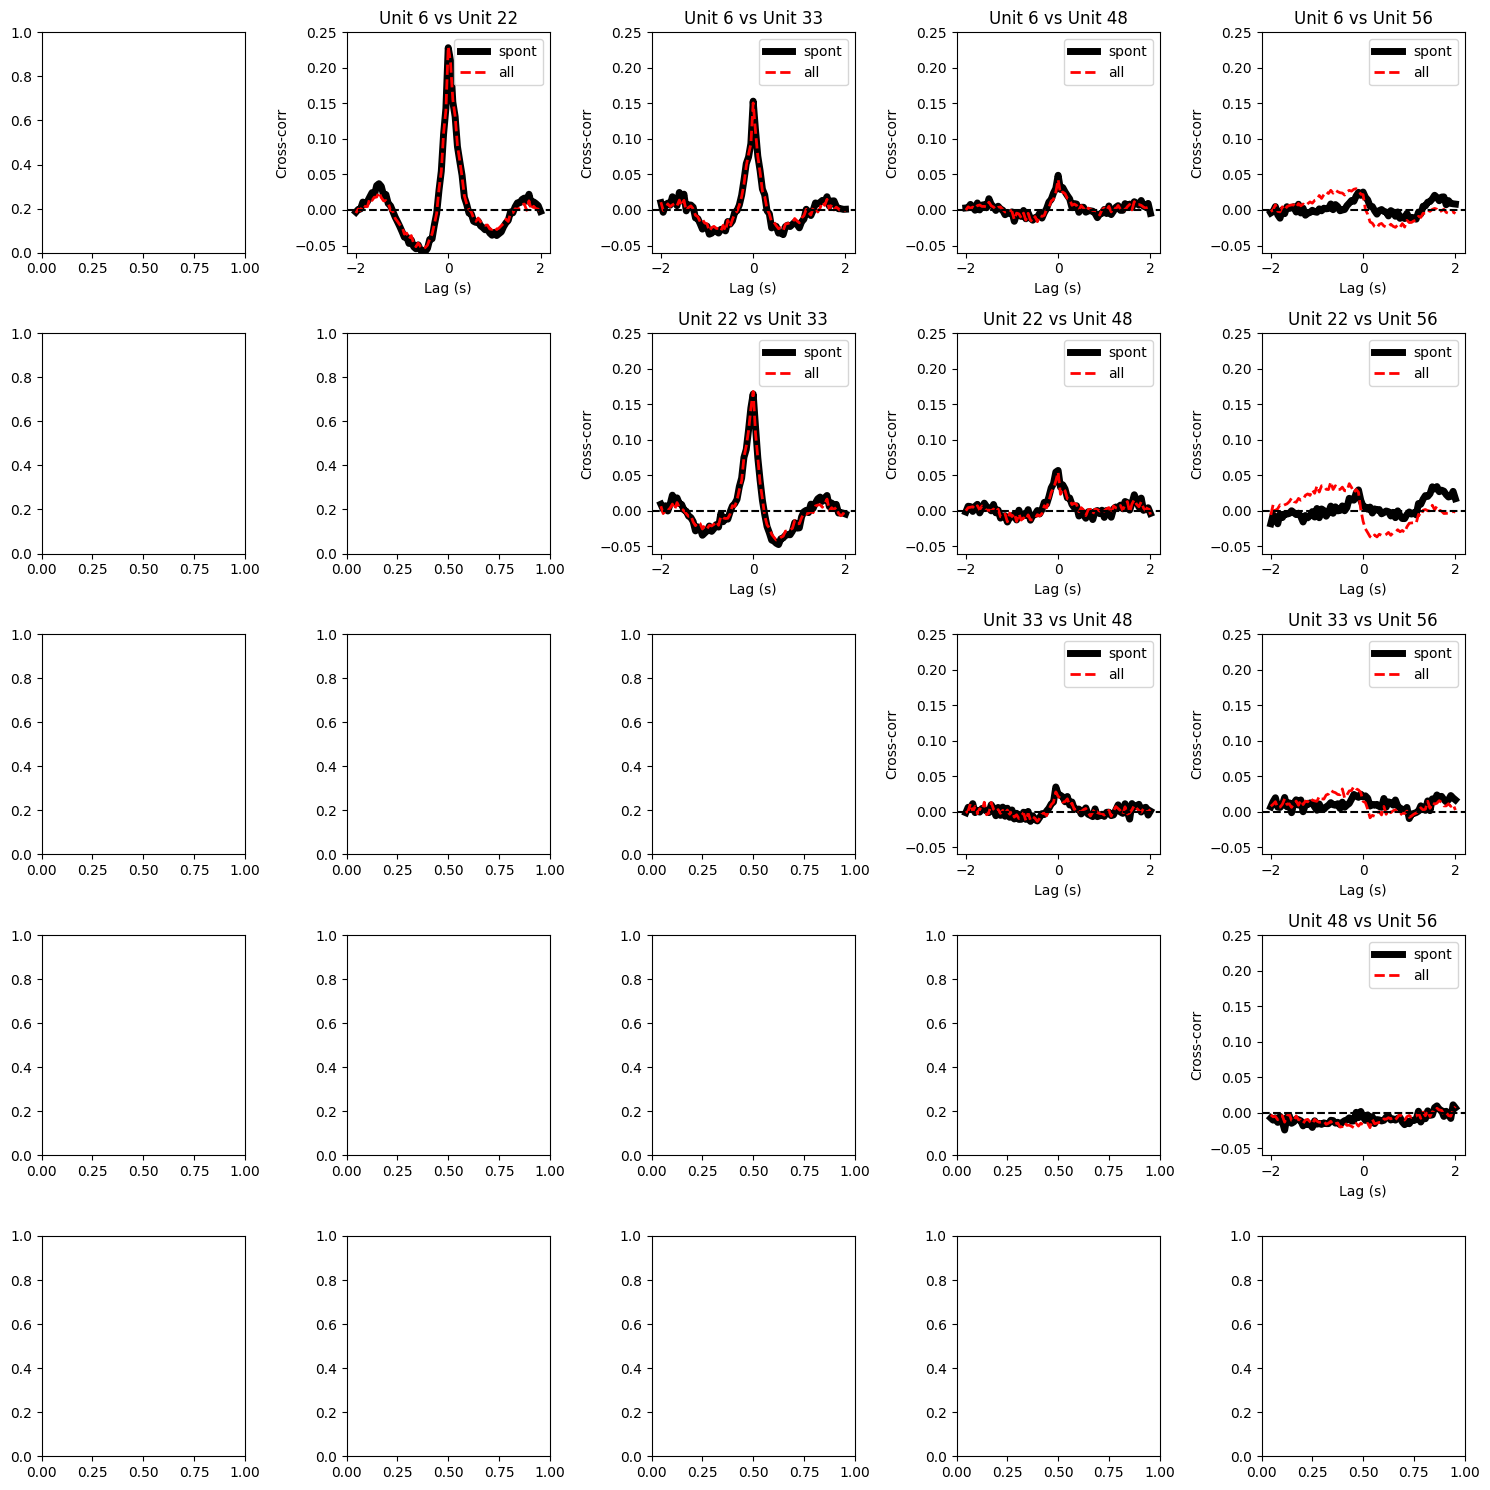

In [16]:
# cross correlation between the examples
fig, axes = plt.subplots(len(unit_list), len(unit_list), figsize=(15, 15))
_cc = {}
for i, unit_id_1 in enumerate(unit_list):
    for j, unit_id_2 in enumerate(unit_list):
        if i >= j:
            continue
        pair_cross = load_cross_corr(example_session, data_type="curated").load_units(unit_id_1, unit_id_2)
        if pair_cross is not None:
            axes[i, j].plot(pair_cross['long_lags'], pair_cross['cross_corr_long_nogo'], linewidth=5, color='k', label = 'spont')
            axes[i, j].plot(pair_cross['long_lags'], pair_cross['cross_corr_long'], linewidth=2, linestyle='--', color='r', label = 'all')
            _cc.setdefault('lag_s', np.asarray(pair_cross['long_lags'])); _cc[f'{unit_id_1}_vs_{unit_id_2}_spont'] = np.asarray(pair_cross['cross_corr_long_nogo']); _cc[f'{unit_id_1}_vs_{unit_id_2}_all'] = np.asarray(pair_cross['cross_corr_long'])
            axes[i, j].axhline(0, color='black', linestyle='--')
            axes[i, j].set_title(f'Unit {unit_id_1} vs Unit {unit_id_2}')
        else:
            axes[i, j].set_title(f'No data for Unit {unit_id_1} vs Unit {unit_id_2}')
        axes[i, j].set_ylim([-0.06, 0.25])
        axes[i, j].set_xlabel('Lag (s)')
        axes[i, j].set_ylabel('Cross-corr')
        axes[i, j].legend()
plt.tight_layout()
save_panels(fig, target_folder, f'example_session_{example_session}_cross_correlation_long', ['FigureE12r_right'], exts=('pdf',))
save_panel_csv(columns_to_df(**_cc), target_folder, f'example_session_{example_session}_cross_correlation_long', ['FigureE12r_right'])
##FigureE12r_right##

### Example Session 2: Raw Trace and Spike Raster Around Two Example Trials

For session `behavior_ZS062_2021-04-02_19-08-52`, render bandpass-filtered raw electrode traces with spike rasters and behavioral event markers (go cues, licks, rewards) overlaid. Saved as Figure4e.

(32, 101835488)


['/root/capsule/scratch/results/manuscript/figures/F_cross_corr/Figure4e_example_session_behavior_ZS062_2021-04-02_19-08-52_rawtrace_firingrate_overlayed_events.csv']

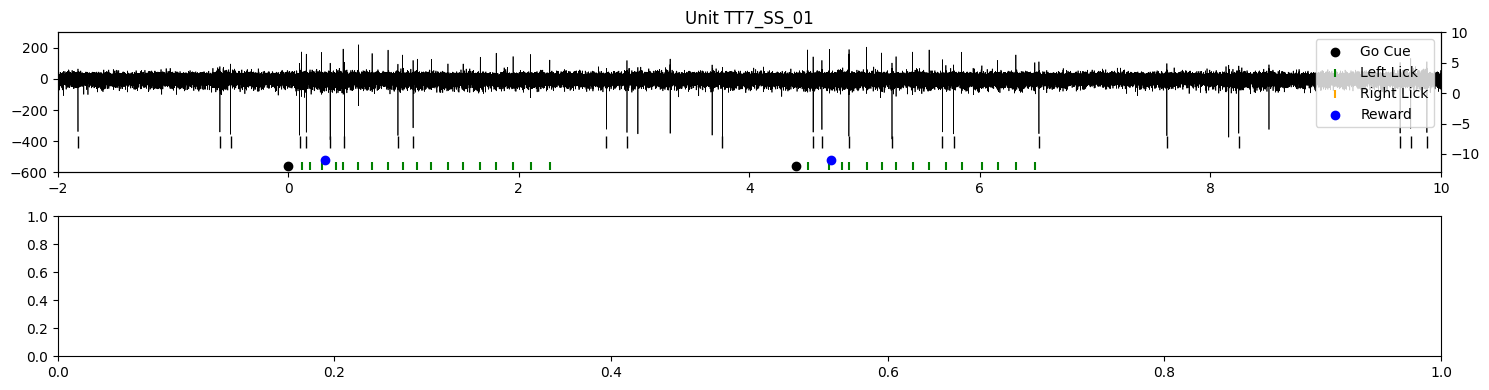

In [17]:
example_session = 'behavior_ZS062_2021-04-02_19-08-52'
licks = load_licks(example_session)
unit_tbl = get_unit_tbl(example_session, data_type="curated")
unit_list = combined_tagged_units_filtered[combined_tagged_units_filtered['session'] == example_session]['unit'].to_list()
session_tbl = get_session_tbl(example_session)
start_time = session_tbl['goCue_start_time'].values[6]
pre_time = -2
post_time = 10

# events
trains_L = licks['lick_trains_L']['train_starts']
trains_R = licks['lick_trains_R']['train_starts']
aligned_L_licks = licks['licks_L_cleaned'] - start_time
aligned_R_licks = licks['licks_R_cleaned']  - start_time 

reward_times = session_tbl[session_tbl['rewarded_historyL'] | session_tbl['rewarded_historyR']]['reward_outcome_time'].values - start_time + 0.2

fig, axes = plt.subplots(len(unit_list), 1, figsize=(15, 2*len(unit_list)), squeeze=False)

go_cue_times = session_tbl['goCue_start_time'].values
_ts = {}; _sp_u = []; _sp_t = []

session_dir = session_dirs(example_session)
rec_file = session_dir['raw_rec']
rec = read_hdf5(rec_file)

# raw trace
start_time_session = rec.get_start_time()
end_time_session = rec.get_end_time()

recording_filtered = spre.bandpass_filter(rec, freq_min=300, freq_max=6000)
recording_filtered = spre.common_reference(recording_filtered)

start_frame = int((start_time + pre_time - start_time_session) * rec.get_sampling_frequency())
end_frame = int((start_time + post_time - start_time_session) * rec.get_sampling_frequency())
traces = recording_filtered.get_traces(segment_index=0, start_frame=start_frame, end_frame=end_frame, return_in_uV=True)

for i, unit_id in enumerate(unit_list[::-2]):
    spike_times = unit_tbl[unit_tbl['unit_id'] == unit_id]['spike_times'].values[0]
    spike_times = spike_times[(spike_times >= start_time + pre_time) & (spike_times <= start_time + post_time)]
    aligned_spikes = spike_times - start_time
    _sp_u.extend([unit_id] * len(aligned_spikes)); _sp_t.extend(np.asarray(aligned_spikes).tolist())

    ax_left = axes[i, 0]          # main axis (raw trace)
    tt_ind = int(unit_id.split('_')[0][2])
    channel_inds = list(range(tt_ind  * 4 - 4, tt_ind  * 4))
    # get waveform of the unit
    unit_waveform = unit_tbl[unit_tbl['unit_id'] == unit_id]['waveform_mean'].values[0]
    # amplitude for each channel
    channel_peak_ind = np.argmax(np.max(unit_waveform, axis=0) - np.min(unit_waveform, axis=0), axis=0)
    raw_trace_time = np.arange(traces.shape[0]) / rec.get_sampling_frequency() + pre_time
    ax_left.plot(raw_trace_time, traces[:, channel_inds[channel_peak_ind]], color='black', linewidth=0.5)
    _ts.setdefault('time_s', np.asarray(raw_trace_time)); _ts[f'{unit_id}_raw_uV'] = traces[:, channel_inds[channel_peak_ind]]
    ax_left.set_ylim([-600, 300])
    ax_right = ax_left.twinx()
    # use left y axis
    ax_left
    # use right y axis
    if i == 0:
        ax_right.scatter(go_cue_times - start_time, np.zeros_like(go_cue_times)-12, color='k', label='Go Cue')
        ax_right.scatter(aligned_L_licks, np.full_like(aligned_L_licks, -12), color='green', label='Left Lick', marker='|')
        ax_right.scatter(aligned_R_licks, np.full_like(aligned_R_licks, -10), color='orange', label='Right Lick', marker='|')
        ax_right.scatter(reward_times, np.full_like(reward_times, -11), color='blue', label='Reward')
    ax_right.eventplot(aligned_spikes, lineoffsets = -8, colors='black', linewidths=1, linelengths=2)
    ax_right.set_title(f'Unit {unit_id}')
    ax_right.set_xlim([pre_time, post_time])
    ax_right.set_ylim(-13, 10)
    ax_right.legend()

plt.xlabel('Time (s)')
plt.tight_layout()
save_panels(fig, target_folder, f'example_session_{example_session}_rawtrace_firingrate_overlayed', ['Figure4e'], exts=('pdf', 'svg'))
# ---- panel CSVs (rule 7: time series + raster + events) ----
_name = f'example_session_{example_session}_rawtrace_firingrate_overlayed'
save_panel_csv(columns_to_df(**_ts), target_folder, _name, ['Figure4e'], plot_type='time_series')
save_panel_csv(columns_to_df(unit_id=_sp_u, spike_time_s=_sp_t), target_folder, _name, ['Figure4e'], plot_type='raster')
save_panel_csv(columns_to_df(go_cue_s=go_cue_times - start_time, left_lick_s=aligned_L_licks, right_lick_s=aligned_R_licks, reward_s=reward_times), target_folder, _name, ['Figure4e'], plot_type='events')
##Figure4e##

# Summarize autocorr and crosscorr features

## Population-Level Cross-Correlation Traces

Plot all cross-correlation traces (long and short timescale) across all unit pairs.

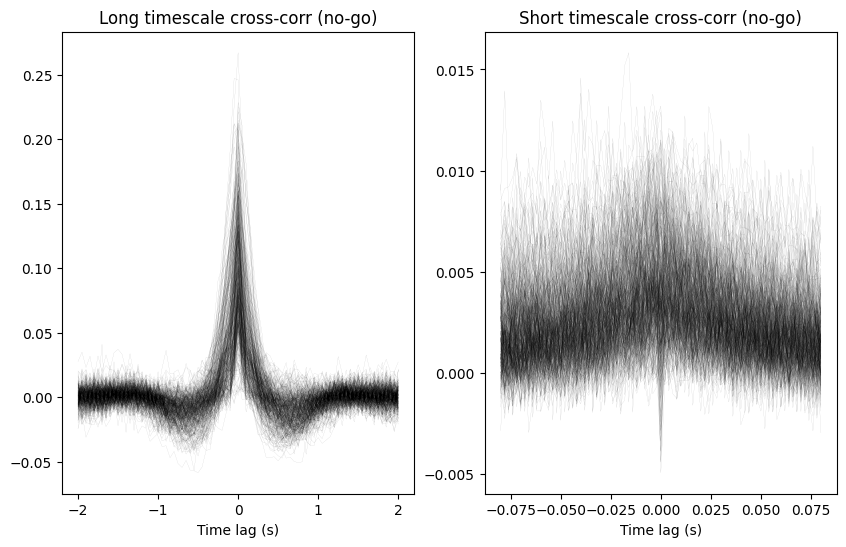

In [18]:
# plot all traces
fig, ax = plt.subplots(1, 2, figsize=(10, 6))
for idx, row in cross_corr_df.iterrows():
    pair_cross = row
    if pair_cross is not None:
        times = pair_cross['long_lags']
        corr_values = pair_cross['cross_corr_long_nogo']
        ax[0].plot(times, corr_values, alpha=0.3, color = 'k', linewidth=0.1)
        times = pair_cross['short_lags']
        corr_values = pair_cross['cross_corr_short_nogo']
        ax[1].plot(times, corr_values, alpha=0.3, color = 'k', linewidth=0.1)
ax[0].set_xlabel('Time lag (s)')
ax[0].set_title('Long timescale cross-corr (no-go)')
ax[1].set_xlabel('Time lag (s)')
ax[1].set_title('Short timescale cross-corr (no-go)')
fig.savefig(os.path.join(target_folder, 'all_unit_pairs_cross_corr.pdf'), dpi=300)

## Dimensionality Reduction: PCA on Cross-Correlation Structure

Apply Principal Component Analysis to the cross-correlation matrices (both long and short timescale) to identify the primary modes of functional connectivity. The PCA reveals whether cross-correlations vary along interpretable dimensions (e.g., excitatory vs inhibitory, fast vs slow dynamics) and quantifies how much variance is captured by each component.

In [19]:
times_long = pair_cross['long_lags']
times_short = pair_cross['short_lags']

In [20]:
all_long_corr = np.array(cross_corr_df['cross_corr_long_nogo'].to_list())
all_short_corr = np.array(cross_corr_df['cross_corr_short_nogo'].to_list())
center_long = all_long_corr[:, all_long_corr.shape[1] // 2]
center_short = all_short_corr[:, all_short_corr.shape[1] // 2]

In [21]:
# zscore

balanced_long_corr = all_long_corr - np.mean(all_long_corr, axis=0, keepdims=True)
balanced_long_corr = zscore(balanced_long_corr, axis=0)
balanced_long_corr = np.concat([balanced_long_corr, np.flip(balanced_long_corr, 1)], axis=0)
all_long_corr_for_plot = np.concat([all_long_corr, np.flip(all_long_corr, 1)], axis=0)

In [22]:
# zscore
balanced_short_corr = all_short_corr - np.mean(all_short_corr, axis=0, keepdims=True)
balanced_short_corr = zscore(balanced_short_corr, axis=0)
balanced_short_corr = np.concat([balanced_short_corr, np.flip(balanced_short_corr, 1)], axis=0)
all_short_corr_for_plot = np.concat([all_short_corr, np.flip(all_short_corr, 1)], axis=0)

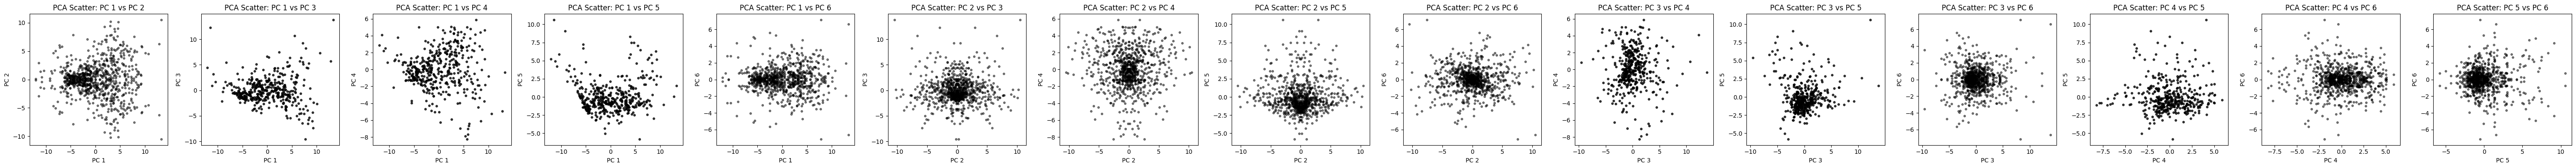

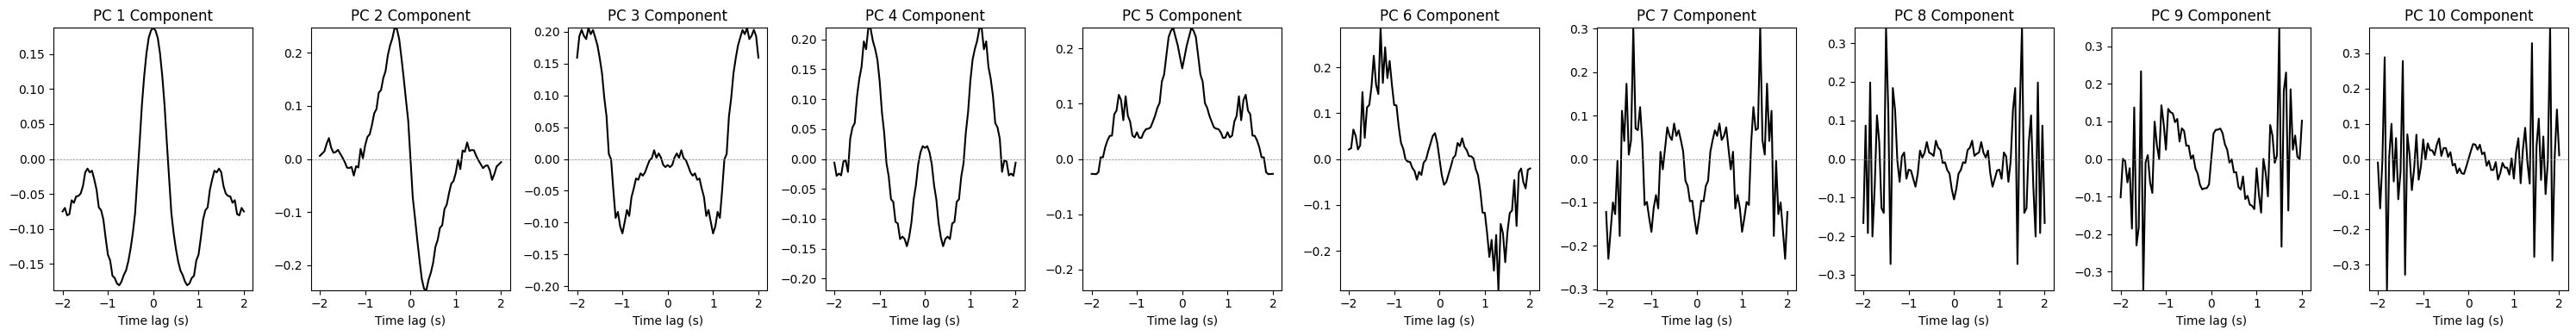

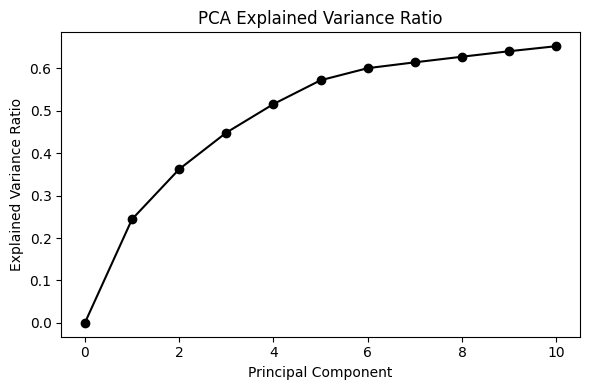

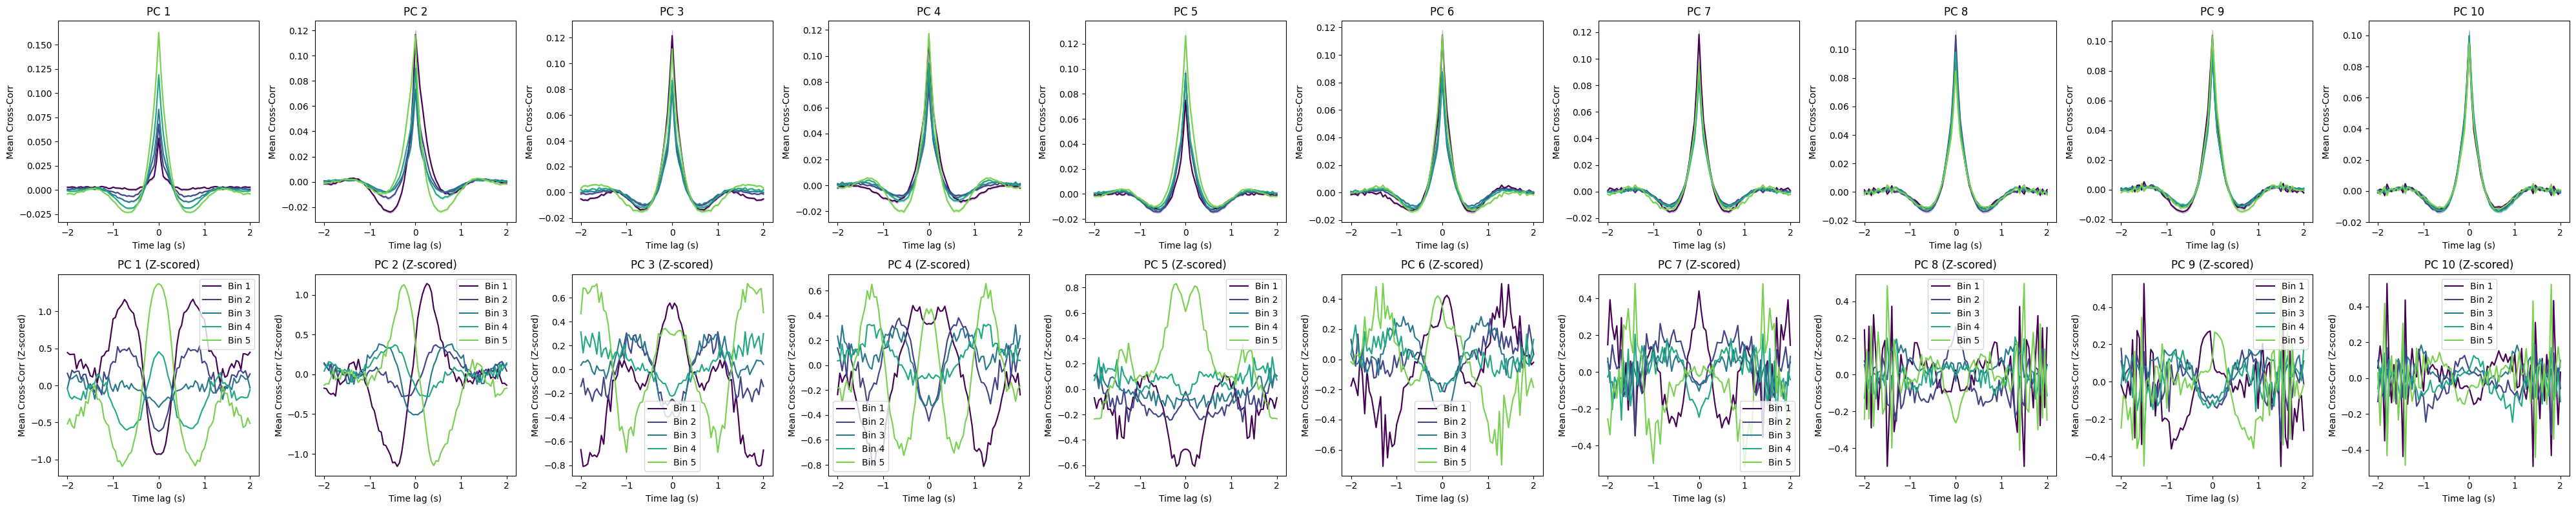

In [23]:
# pca on long timescale cross-corr long term
num_components = 10
pca = PCA(n_components=num_components)
pca.fit(balanced_long_corr)
long_corr_pca = pca.transform(balanced_long_corr)
import matplotlib.pyplot as plt


def plot_pca_pairs(pca_data, max_components=None, figsize=(12, 4)):
    """
    pca_data: array (n_samples × n_components)
    max_components: number of components to visualize (default = all)
    """

    # Determine how many components to use
    n_components = pca_data.shape[1]
    if max_components is not None:
        n_components = min(max_components, n_components)

    component_indices = range(n_components)

    # Generate all unique pairs: (0,1), (0,2), (1,2), ...
    pairs = list(itertools.combinations(component_indices, 2))

    # Determine layout
    n_plots = len(pairs)
    fig, axes = plt.subplots(1, n_plots, figsize=(4 * n_plots, 4), squeeze=False)
    axes = axes.ravel()

    # Plot each pair
    for ax, (i, j) in zip(axes, pairs):
        ax.scatter(pca_data[:, i], pca_data[:, j], alpha=0.5, color='k', s=10)
        ax.set_xlabel(f"PC {i+1}")
        ax.set_ylabel(f"PC {j+1}")
        ax.set_title(f"PCA Scatter: PC {i+1} vs PC {j+1}")

    plt.tight_layout()
    return fig, axes

fig, axes = plot_pca_pairs(long_corr_pca, max_components=6)

# plot component of each PC
fig, ax = plt.subplots(1, num_components, figsize=(3*num_components, 4))
lags = cross_corr_df.iloc[0]['long_lags']
for i in range(num_components):
    ax[i].plot(lags, pca.components_[i], color='k')
    ax[i].set_title(f'PC {i+1} Component')
    ax[i].set_xlabel('Time lag (s)')
    amp = np.max(np.abs(pca.components_[i]))
    ax[i].set_ylim([-amp, amp])
    ax[i].axhline(0, color='gray', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.savefig(os.path.join(target_folder, 'cross_corr_pca_components.pdf'), dpi=300)  

# plot explained variance
explained_variance = pca.explained_variance_ratio_
explained_variance = np.cumsum(explained_variance)
explained_variance = np.insert(explained_variance, 0, 0)
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
ax.plot(range(len(explained_variance)), explained_variance, marker='o', color='k')
ax.set_xlabel('Principal Component')
ax.set_ylabel('Explained Variance Ratio')
ax.set_title('PCA Explained Variance Ratio')
plt.tight_layout()
plt.savefig(os.path.join(target_folder, 'cross_corr_pca_explained_variance.pdf'), dpi=300)

# plot mean of cross correltions binned by score of each pc
num_bins = 5
fig, axes = plt.subplots(2, num_components, figsize=(4*num_components, 8))
for pc_idx in range(num_components):
    pc_scores = long_corr_pca[:, pc_idx]
    bin_edges = np.percentile(pc_scores, np.linspace(0, 100, num_bins + 1))
    binned_means = []
    binned_means_ori = []
    binned_sems = []
    binned_sems_ori = []
    for i in range(num_bins):
        bin_mask = (pc_scores >= bin_edges[i]) & (pc_scores < bin_edges[i + 1])
        bin_data = all_long_corr_for_plot[bin_mask]
        bin_data_ori = balanced_long_corr[bin_mask]
        mean_corr = np.mean(bin_data, axis=0)
        mean_corr_ori = np.mean(bin_data_ori, axis=0)
        sem_corr = np.std(bin_data, axis=0) / np.sqrt(bin_data.shape[0])
        sem_corr_ori = np.std(bin_data_ori, axis=0) / np.sqrt(bin_data_ori.shape[0])
        binned_means.append(mean_corr)
        binned_means_ori.append(mean_corr_ori)
        binned_sems.append(sem_corr)
        binned_sems_ori.append(sem_corr)
    
    # Plotting
    ax = axes[0, pc_idx]
    lags = cross_corr_df.iloc[0]['long_lags']
    for i in range(num_bins):
        ax.plot(lags, binned_means[i], label=f'Bin {i+1}', color=plt.cm.viridis(i / num_bins))
        ax.fill_between(lags, 
                        binned_means[i] - binned_sems[i], 
                        binned_means[i] + binned_sems[i], 
                        alpha=0.2, 
                        color=plt.cm.viridis(i / num_bins)
        )
    ax.set_title(f'PC {pc_idx+1}')
    ax.set_xlabel('Time lag (s)')
    ax.set_ylabel('Mean Cross-Corr')
    
    ax = axes[1, pc_idx]
    for i in range(num_bins):
        ax.plot(lags, binned_means_ori[i], label=f'Bin {i+1}', color=plt.cm.viridis(i / num_bins))
        ax.fill_between(lags, 
                        binned_means_ori[i] - binned_sems_ori[i], 
                        binned_means_ori[i] + binned_sems_ori[i], 
                        alpha=0.2, 
                        color=plt.cm.viridis(i / num_bins)
        )
    ax.set_title(f'PC {pc_idx+1} (Z-scored)')
    ax.set_xlabel('Time lag (s)')
    ax.set_ylabel('Mean Cross-Corr (Z-scored)')

    ax.legend()
    plt.tight_layout()
fig.savefig(os.path.join(target_folder, 'cross_corr_pca_binned_means.pdf'), dpi=300)

['/root/capsule/scratch/results/manuscript/figures/F_cross_corr/FigureS15s_cross_corr_example_sorted_by_pc1.csv']

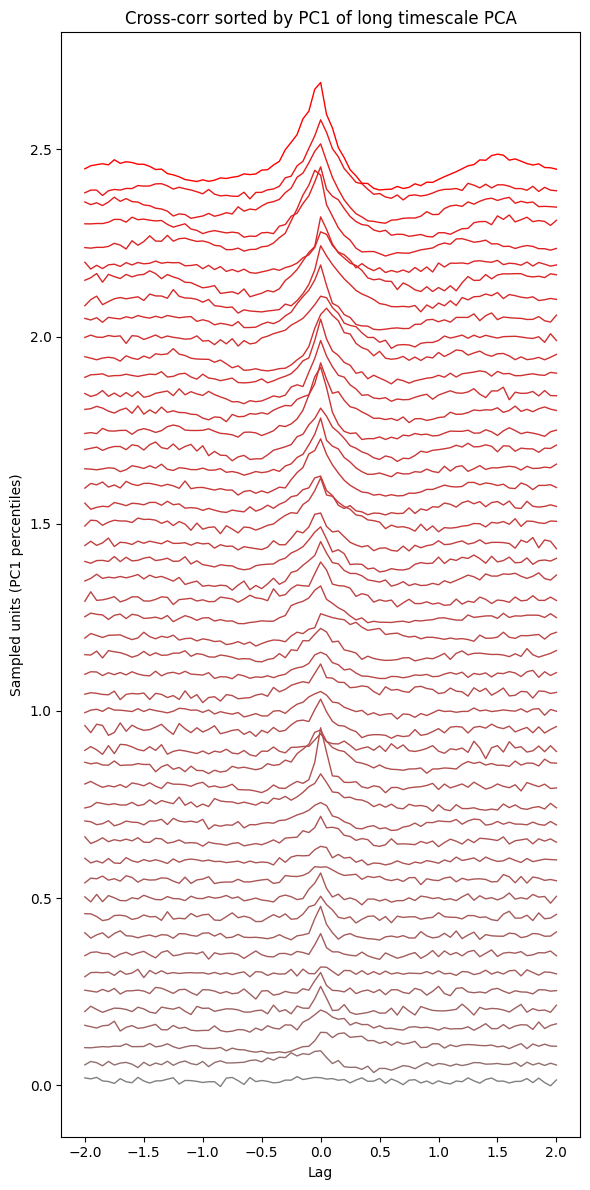

In [24]:
# plot on PC1 of long time scale PCA
fig, ax = plt.subplots(figsize=(6, 12))

pc1_scores = long_corr_pca[:, 0]

# sort by PC1
sorted_indices = np.argsort(pc1_scores)
sorted_pc1_scores = pc1_scores[sorted_indices]
sorted_corr_values = np.asarray(all_long_corr_for_plot)[sorted_indices]

lags = np.asarray(cross_corr_df.iloc[0]['long_lags'])

# number of samples
n_sample = 50

# pick indices at equal percentiles
percentile_positions = np.linspace(0, len(sorted_pc1_scores) - 1, n_sample).astype(int)

sample_pc1 = sorted_pc1_scores[percentile_positions]
sample_corr = sorted_corr_values[percentile_positions]

# normalize PC1 scores for colormap
pc1_min = sorted_pc1_scores.min()
pc1_range = sorted_pc1_scores.max() - pc1_min
pc1_norm = (sample_pc1 - pc1_min) / (pc1_range if pc1_range > 0 else 1)

# custom colormap
custom_cmap = LinearSegmentedColormap.from_list(
    "pc1_score", [(0.0, "gray"), (1.0, "red")]
)

offset = 0.05
for i, (corr, cval) in enumerate(zip(sample_corr, pc1_norm)):
    ax.plot(
        lags,
        corr + i * offset,
        color=custom_cmap(cval),
        linewidth=1,
    )

ax.set_xlabel("Lag")
ax.set_ylabel("Sampled units (PC1 percentiles)")
ax.set_title("Cross-corr sorted by PC1 of long timescale PCA")
plt.tight_layout()
save_panels(fig, target_folder, 'cross_corr_example_sorted_by_pc1', ['FigureE12s'], exts=('pdf',), dpi=300)
# ---- panel CSV (rule 3: time series, sampled traces + PC1 colorcode) ----
_c = {'lag': np.asarray(lags)}
for _i in range(len(sample_corr)):
    _c[f'sample_{_i}'] = np.asarray(sample_corr[_i])
save_panel_csv(columns_to_df(**_c), target_folder, 'cross_corr_example_sorted_by_pc1', ['FigureE12s'])
##FigureE12s##

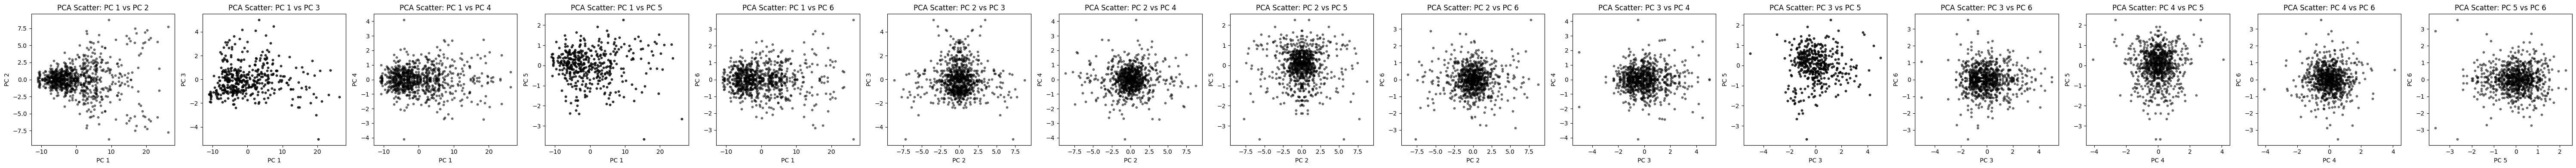

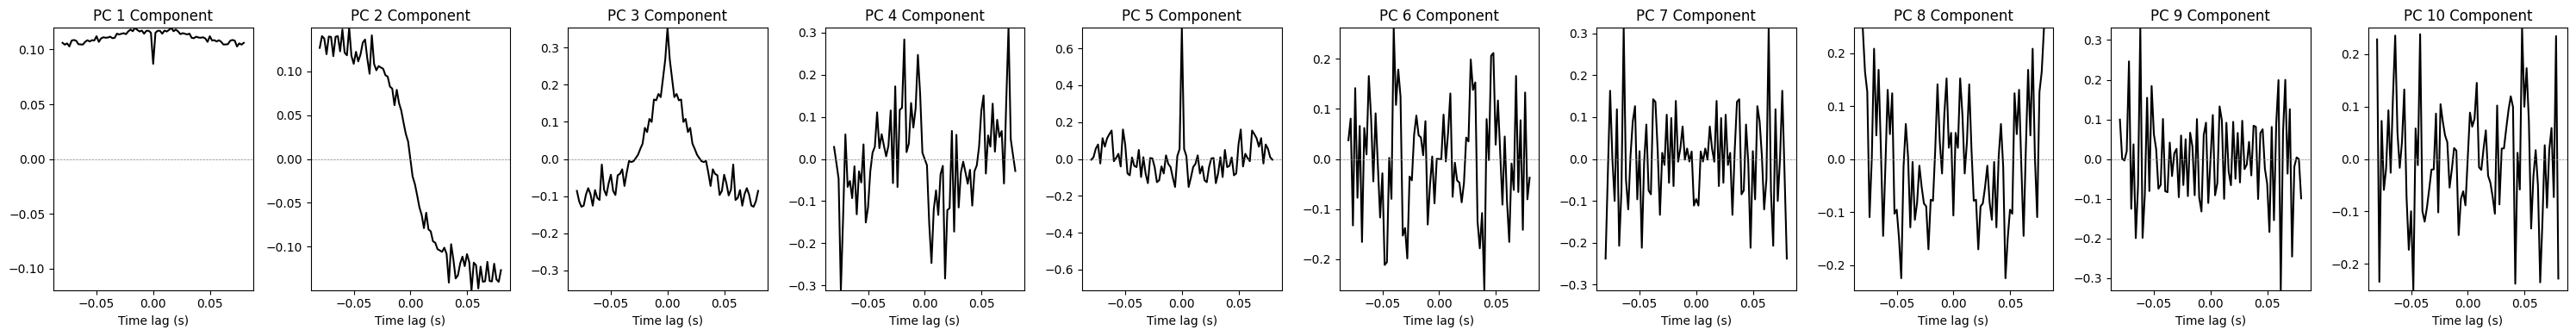

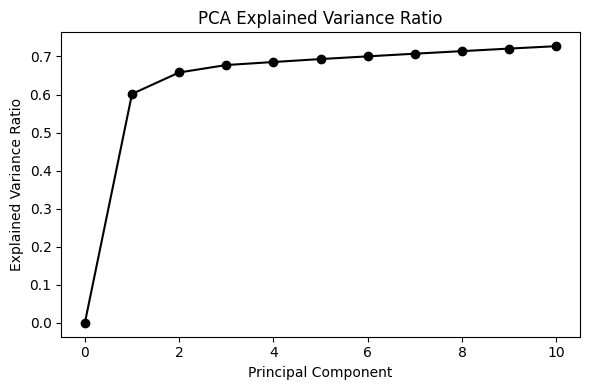

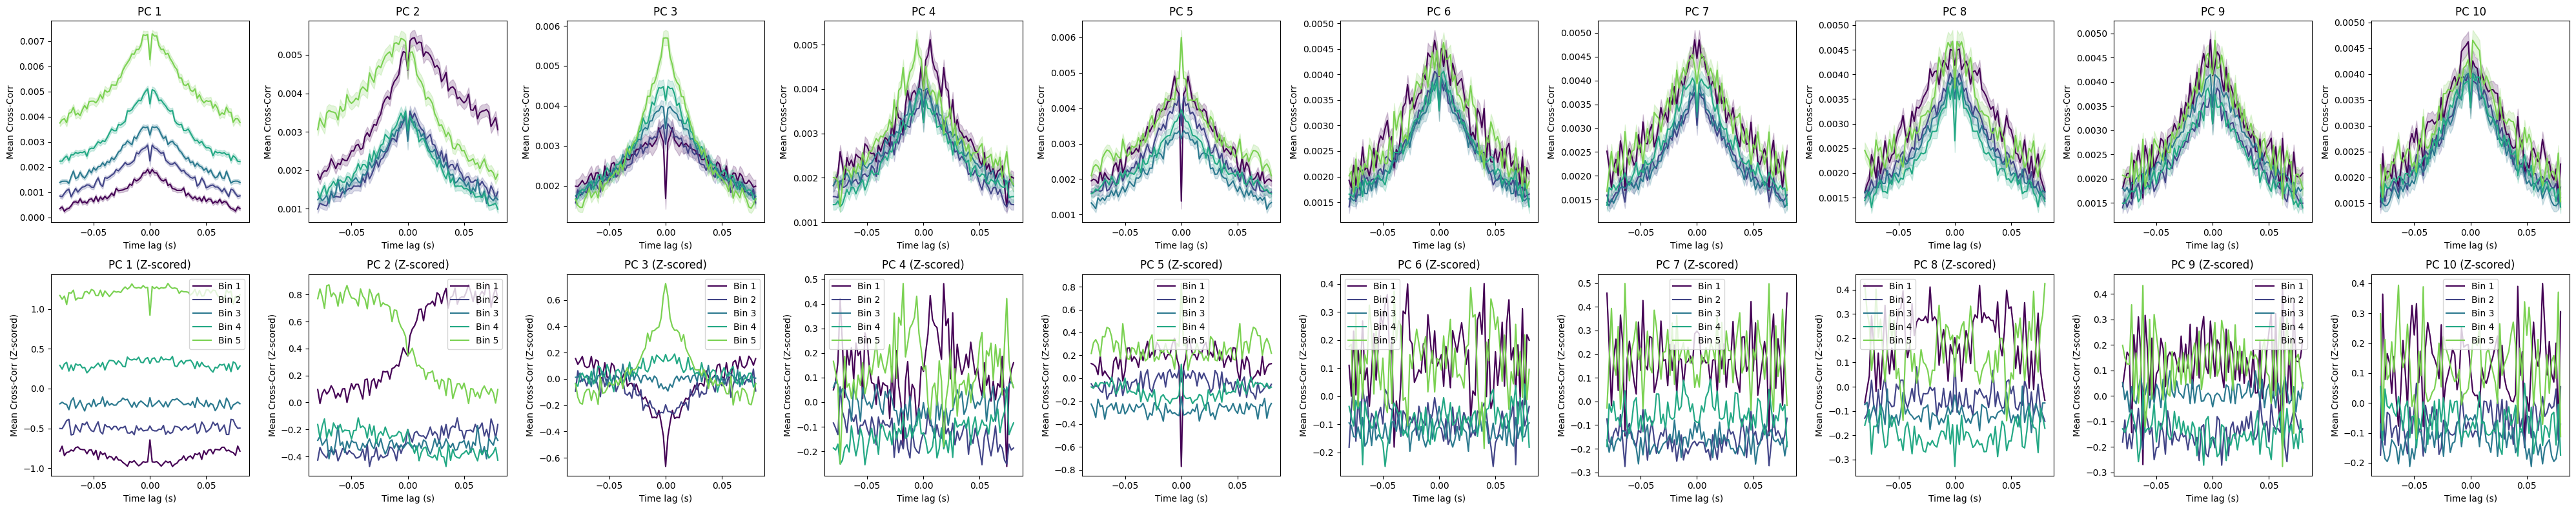

In [25]:
# pca on short timescale cross-corr
num_components = 10
pca = PCA(n_components=num_components)
pca.fit(balanced_short_corr)
short_corr_pca = pca.transform(balanced_short_corr)

fig, axes = plot_pca_pairs(short_corr_pca, max_components=6)
 
# plot component of each PC
fig, ax = plt.subplots(1, num_components, figsize=(3*num_components, 4))
lags = cross_corr_df.iloc[0]['short_lags']
for i in range(num_components):
    ax[i].plot(lags, pca.components_[i], color='k')
    ax[i].set_title(f'PC {i+1} Component')
    ax[i].set_xlabel('Time lag (s)')
    amp = np.max(np.abs(pca.components_[i]))
    ax[i].set_ylim([-amp, amp])
    ax[i].axhline(0, color='gray', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.savefig(os.path.join(target_folder, 'cross_corr_pca_components_short.pdf'), dpi=300)  

# plot explained variance
explained_variance = pca.explained_variance_ratio_
explained_variance = np.cumsum(explained_variance)
explained_variance = np.insert(explained_variance, 0, 0)
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
ax.plot(range(len(explained_variance)), explained_variance, marker='o', color='k')
ax.set_xlabel('Principal Component')
ax.set_ylabel('Explained Variance Ratio')
ax.set_title('PCA Explained Variance Ratio')
plt.tight_layout()
plt.savefig(os.path.join(target_folder, 'cross_corr_pca_explained_variance_short.pdf'), dpi=300)

# plot mean of cross correltions binned by score of each pc
num_bins = 5
fig, axes = plt.subplots(2, num_components, figsize=(4*num_components, 8))
for pc_idx in range(num_components):
    pc_scores = short_corr_pca[:, pc_idx]
    bin_edges = np.percentile(pc_scores, np.linspace(0, 100, num_bins + 1))
    binned_means = []
    binned_means_ori = []
    binned_sems = []
    binned_sems_ori = []
    for i in range(num_bins):
        bin_mask = (pc_scores >= bin_edges[i]) & (pc_scores < bin_edges[i + 1])
        bin_data = all_short_corr_for_plot[bin_mask]
        bin_data_ori = balanced_short_corr[bin_mask]
        mean_corr = np.mean(bin_data, axis=0)
        mean_corr_ori = np.mean(bin_data_ori, axis=0)
        sem_corr = np.std(bin_data, axis=0) / np.sqrt(bin_data.shape[0])
        sem_corr_ori = np.std(bin_data_ori, axis=0) / np.sqrt(bin_data_ori.shape[0])
        binned_means.append(mean_corr)
        binned_means_ori.append(mean_corr_ori)
        binned_sems.append(sem_corr)
        binned_sems_ori.append(sem_corr)
    
    # Plotting
    ax = axes[0, pc_idx]
    lags = cross_corr_df.iloc[0]['short_lags']
    for i in range(num_bins):
        ax.plot(lags, binned_means[i], label=f'Bin {i+1}', color=plt.cm.viridis(i / num_bins))
        ax.fill_between(lags, 
                        binned_means[i] - binned_sems[i], 
                        binned_means[i] + binned_sems[i], 
                        alpha=0.2, 
                        color=plt.cm.viridis(i / num_bins)
        )
    ax.set_title(f'PC {pc_idx+1}')
    ax.set_xlabel('Time lag (s)')
    ax.set_ylabel('Mean Cross-Corr')
    
    ax = axes[1, pc_idx]
    for i in range(num_bins):
        ax.plot(lags, binned_means_ori[i], label=f'Bin {i+1}', color=plt.cm.viridis(i / num_bins))
        ax.fill_between(lags, 
                        binned_means_ori[i] - binned_sems_ori[i], 
                        binned_means_ori[i] + binned_sems_ori[i], 
                        alpha=0.2, 
                        color=plt.cm.viridis(i / num_bins)
        )
    ax.set_title(f'PC {pc_idx+1} (Z-scored)')
    ax.set_xlabel('Time lag (s)')
    ax.set_ylabel('Mean Cross-Corr (Z-scored)')

    ax.legend()
    plt.tight_layout()
fig.savefig(os.path.join(target_folder, 'cross_corr_pca_binned_means_short.pdf'), dpi=300)

## Assign PC Scores and Compute Summary Features

Attach long- and short-timescale PCA scores (PC1, PC2) to the cross-correlation dataframe. Compute scalar summary metrics per pair — peak synchrony, inhibitory-window area, and directional asymmetry — and append CCF distance and ranked anatomical coordinates used in spatial analyses.

In [26]:
# flip units based on sign of PC2
cross_corr_df_flipped = cross_corr_df.copy()
scores_pc2 = pca.transform(balanced_long_corr[:len(all_long_corr), :])[ :, 1]
flip_indices = scores_pc2 < 0
cross_corr_df_flipped.loc[flip_indices, 'unit_1'], cross_corr_df_flipped.loc[flip_indices, 'unit_2'] = \
    cross_corr_df_flipped.loc[flip_indices, 'unit_2'], cross_corr_df_flipped.loc[flip_indices, 'unit_1'].values
cross_corr_df_flipped.loc[flip_indices, 'y_loc_1'], cross_corr_df_flipped.loc[flip_indices, 'y_loc_2'] = \
    cross_corr_df_flipped.loc[flip_indices, 'y_loc_2'], cross_corr_df_flipped.loc[flip_indices, 'y_loc_1'].values
cross_corr_df_flipped.loc[flip_indices, 'x_ccf_1'], cross_corr_df_flipped.loc[flip_indices, 'x_ccf_2'] = \
    cross_corr_df_flipped.loc[flip_indices, 'x_ccf_2'], cross_corr_df_flipped.loc[flip_indices, 'x_ccf_1'].values
cross_corr_df_flipped.loc[flip_indices, 'y_ccf_1'], cross_corr_df_flipped.loc[flip_indices, 'y_ccf_2'] = \
    cross_corr_df_flipped.loc[flip_indices, 'y_ccf_2'], cross_corr_df_flipped.loc[flip_indices, 'y_ccf_1'].values
cross_corr_df_flipped.loc[flip_indices, 'z_ccf_1'], cross_corr_df_flipped.loc[flip_indices, 'z_ccf_2'] = \
    cross_corr_df_flipped.loc[flip_indices, 'z_ccf_2'], cross_corr_df_flipped.loc[flip_indices, 'z_ccf_1'].values
cross_corr_df_flipped.loc[flip_indices, 'cross_corr_long_nogo'] = \
    cross_corr_df_flipped.loc[flip_indices, 'cross_corr_long_nogo'].apply(lambda x: np.flip(x))
cross_corr_df_flipped.loc[flip_indices, 'cross_corr_short_nogo'] = \
    cross_corr_df_flipped.loc[flip_indices, 'cross_corr_short_nogo'].apply(lambda x: np.flip(x))

In [27]:
PC_1 = long_corr_pca[:len(all_long_corr), 0]
cross_corr_df['PC_1'] = PC_1
PC_2 = long_corr_pca[:len(all_long_corr), 1]
cross_corr_df['PC_2'] = PC_2

In [28]:
peak_win = [0, 7]
inhi_win = [7, 30]
print(f'Long peak window: {times_long[len(times_long)//2]:.3f} to {times_long[len(times_long)//2 + peak_win[1]]:.3f} s')
print(f'Long inhi window: {times_long[len(times_long)//2 + inhi_win[0]]:.3f} to {times_long[len(times_long)//2 + inhi_win[1]]:.3f} s')

Long peak window: 0.000 to 0.350 s
Long inhi window: 0.350 to 1.500 s


## Extract Summary Features from Cross-Correlations

Compute quantitative features that summarize cross-correlation structure for each unit pair:
- Peak cross-correlation values (synchrony strength)
- Inhibitory window metrics (delayed suppression)
- Asymmetry measures (directional interactions)

These features enable statistical testing of how functional connectivity varies with anatomical location and behavioral encoding.

In [30]:
# append ccf location
bregma_LPS_mm = np.array([-5.74, 5.4, -0.45])  # in mm
# diff
distance_abs = np.abs(cross_corr_df['y_loc_2'].values - cross_corr_df['y_loc_1'].values)
distance_abs[cross_corr_df['session'].apply(lambda x: 'ZS' in x).values] = np.nan  # exclude old sessions for y distance
distance = (cross_corr_df['y_loc_2'].values - cross_corr_df['y_loc_1'].values)
distance[cross_corr_df['session'].apply(lambda x: 'ZS' in x).values] = np.nan  # exclude old sessions for y distance
distance_x = (cross_corr_df['x_ccf_2'].values - cross_corr_df['x_ccf_1'].values)
distance_x[cross_corr_df['session'].apply(lambda x: 'ZS' in x).values] = np.nan  # exclude old sessions for y distance
distance_z = (cross_corr_df['z_ccf_2'].values - cross_corr_df['z_ccf_1'].values)
distance_z[cross_corr_df['session'].apply(lambda x: 'ZS' in x).values] = np.nan  # exclude old sessions for y distance
distance_y = (cross_corr_df['y_ccf_2'].values - cross_corr_df['y_ccf_1'].values)
distance_y[cross_corr_df['session'].apply(lambda x: 'ZS' in x).values] = np.nan  # exclude old sessions for y distance

# rank before adding to dataframe
# rank and center to where distance is 0
dis_sign = np.sign(distance_x)
distance_x_log = np.log(np.abs(1000*distance_x)) * dis_sign

cross_corr_df['distance_abs'] = distance_abs
cross_corr_df['distance'] = distance
cross_corr_df['distance_x'] = distance_x_log
cross_corr_df['distance_z'] = distance_z
cross_corr_df['distance_y'] = distance_y

# mean
mean_z_ccf = (cross_corr_df['z_ccf_1'].values + cross_corr_df['z_ccf_2'].values) / 2
mean_z_ccf[cross_corr_df['session'].apply(lambda x: 'ZS' in x).values] = np.nan  # exclude old sessions for y distance
mean_y_ccf = (cross_corr_df['y_ccf_1'].values + cross_corr_df['y_ccf_2'].values) / 2
mean_y_ccf[cross_corr_df['session'].apply(lambda x: 'ZS' in x).values] = np.nan  # exclude old sessions for y distance
mean_x_ccf = (cross_corr_df['x_ccf_1'].values + cross_corr_df['x_ccf_2'].values) / 2
mean_x_ccf[cross_corr_df['session'].apply(lambda x: 'ZS' in x).values] = np.nan  # exclude old sessions for y distance

cross_corr_df['mean_z_ccf'] = mean_z_ccf
cross_corr_df['mean_y_ccf'] = mean_y_ccf
cross_corr_df['mean_x_ccf'] = mean_x_ccf

# # rank ccf location
mean_x_ccf[~np.isnan(mean_x_ccf)] = rankdata(mean_x_ccf[~np.isnan(mean_x_ccf)])
mean_y_ccf[~np.isnan(mean_y_ccf)] = rankdata(mean_y_ccf[~np.isnan(mean_y_ccf)])
mean_z_ccf[~np.isnan(mean_z_ccf)] = rankdata(mean_z_ccf[~np.isnan(mean_z_ccf)])

cross_corr_df['mean_z_ccf_rank'] = mean_z_ccf
cross_corr_df['mean_y_ccf_rank'] = mean_y_ccf
cross_corr_df['mean_x_ccf_rank'] = mean_x_ccf

# Long: cross-corr metrics
peak_cross = [cross_corr_df.iloc[i]['cross_corr_long_nogo'][len(cross_corr_df.iloc[i]['cross_corr_long_nogo']) // 2] for i in range(len(cross_corr_df))]
peak_cross = np.array(peak_cross)
peak_win_cross = [np.mean(cross_corr_df.iloc[i]['cross_corr_long_nogo'][len(cross_corr_df.iloc[i]['cross_corr_long_nogo']) // 2 - peak_win[1]: len(cross_corr_df.iloc[i]['cross_corr_long_nogo']) // 2 + peak_win[1]]) for i in range(len(cross_corr_df))]
peak_win_cross = np.array(peak_win_cross)
inhi_win_cross_outer = [np.sum(cross_corr_df.iloc[i]['cross_corr_long_nogo'][len(cross_corr_df.iloc[i]['cross_corr_long_nogo']) // 2 - inhi_win[1]: len(cross_corr_df.iloc[i]['cross_corr_long_nogo']) // 2 + inhi_win[1]]) for i in range(len(cross_corr_df))]
inhi_win_cross_outer = np.array(inhi_win_cross_outer)
inhi_win_cross_inner = [np.sum(cross_corr_df.iloc[i]['cross_corr_long_nogo'][len(cross_corr_df.iloc[i]['cross_corr_long_nogo']) // 2 - inhi_win[0]: len(cross_corr_df.iloc[i]['cross_corr_long_nogo']) // 2 + inhi_win[0]]) for i in range(len(cross_corr_df))]
inhi_win_cross_inner = np.array(inhi_win_cross_inner)
inhi_win_cross = inhi_win_cross_outer - inhi_win_cross_inner
inhi_win_asy_cross_right = [np.mean(cross_corr_df.iloc[i]['cross_corr_long_nogo'][len(cross_corr_df.iloc[i]['cross_corr_long_nogo']) // 2 + inhi_win[0]: len(cross_corr_df.iloc[i]['cross_corr_long_nogo']) // 2 + inhi_win[1]]) 
                            for i in range(len(cross_corr_df))]
inhi_win_asy_cross_left = [np.mean(cross_corr_df.iloc[i]['cross_corr_long_nogo'][len(cross_corr_df.iloc[i]['cross_corr_long_nogo']) // 2 - inhi_win[1]: len(cross_corr_df.iloc[i]['cross_corr_long_nogo']) // 2 - inhi_win[0]]) 
                           for i in range(len(cross_corr_df))]
inhi_win_asy_cross = (np.array(inhi_win_asy_cross_right) - np.array(inhi_win_asy_cross_left))/(peak_cross+0.2)

# rank peak cross

cross_corr_df['peak_cross'] = peak_cross
cross_corr_df['inhi_win_cross'] = inhi_win_cross
cross_corr_df['peak_win_cross'] = peak_win_cross
cross_corr_df['inhi_win_asy_cross'] = inhi_win_asy_cross

# short
peak_cross_short = [cross_corr_df.iloc[i]['cross_corr_short_nogo'][len(cross_corr_df.iloc[i]['cross_corr_short_nogo']) // 2] for i in range(len(cross_corr_df))]
peak_cross_short = np.array(peak_cross_short)
cross_corr_df['peak_cross_short'] = peak_cross_short
PC_1 = short_corr_pca[:len(all_short_corr), 0]
PC_2 = short_corr_pca[:len(all_short_corr), 1]
cross_corr_df['PC_1_short'] = PC_1
cross_corr_df['PC_2_short'] = PC_2

In [31]:
focus_features = ['PC_1', 'PC_1_short', 'peak_cross_short',
                'inhi_win_cross', 'peak_win_cross']

In [32]:
ml, ap, dv = 0, 1, 2
planes = {'sag': [ap, dv], 'hor': [ml, ap], 'cor': [ml, dv]}
ccfs = cross_corr_df[['mean_x_ccf', 'mean_y_ccf', 'mean_z_ccf']].values
bregma_LPS_mm = np.array([-5.74, 5.4, -0.45])
ccfs = ccfs - bregma_LPS_mm
ccfs[:, ml] = np.abs(ccfs[:, ml])  # mirror ML to left

## Relate Cross-Correlation Features to Behavioral and Waveform Spatial Axes

Project CCF coordinates onto spatial axes derived from behavioral encoding and waveform PCA analyses. The following sections test whether cross-correlation PC1 varies along the same spatial gradients that organize task responses or cell-type composition across PrL and S1.

In [33]:
# compute spatial dependence for each feature
spatial_dependence_results = {}
for feature in focus_features:
    values = cross_corr_df[feature].values
    results = spatial_dependence_summary(ccfs, values, k_neighbors=30, n_splits=5, permutations=5000, seed=42)
    spatial_dependence_results[feature] = results

### Project onto Behavioral Encoding Axes

Load the behavioral-encoding spatial axes from `spatial_dependence_results_beh_all.pkl`, project each unit pair's mean CCF location onto those axes, and test correlation with cross-correlation PC1. Results are plotted as scatter panels and saved as FigureE12t.

In [34]:
# families = {'long': ['PC_1', 'PC_2', 'inhi_win_cross', 'peak_win_cross', 'inhi_win_asy_cross'],
#             'short': ['PC_1_short', 'PC_2_short', 'peak_cross_short']}

families = {'long': ['PC_1', 'inhi_win_cross', 'peak_win_cross'],
            'short': ['PC_1_short','peak_cross_short']}

# family-wise multiple comparison correction
for family_name, feature_list in families.items():
    p_values = [spatial_dependence_results[feature]['cv_predictability_knn']['p_value_permutation'] for feature in feature_list]
    reject, pvals_corrected, _, _ = multipletests(p_values, alpha=0.05, method='fdr_bh')
    for i, feature in enumerate(feature_list):
        spatial_dependence_results[feature]['cv_predictability_knn']['p_value_permutation_fdr'] = pvals_corrected[i]
        spatial_dependence_results[feature]['cv_predictability_knn']['significant_fdr'] = reject[i]
    p_values = [spatial_dependence_results[feat]['linear_trend']['p_value_permutation_r2'] for feat in focus_features]
    reject, pvals_corrected, _, _ = multipletests(p_values, alpha=0.05, method='fdr_bh')
    for i, feature in enumerate(focus_features):
        spatial_dependence_results[feature]['linear_trend']['p_value_permutation_r2_fdr'] = pvals_corrected[i]
        spatial_dependence_results[feature]['linear_trend']['significant_fdr'] = reject[i]

## Relate Cross-Correlation Features to Behavioral Encoding Axes

Project CCF coordinates of unit pairs onto the behavioral encoding spatial axes and test whether cross-correlation PC1 varies along those axes.

In [35]:
# plot features along the axis inferrd from behavior encodings
spatial_test_file = os.path.join(os.path.join(capsule_dirs["manuscript_fig_dir"], 'F_ephys_beh_action&outcome'), 'spatial_dependence_results_beh_all.pkl')
with open(spatial_test_file, 'rb') as f:
    spatial_dependence_beh = pickle.load(f)

In [36]:
correlation_results = {}
for ind, feature in enumerate(focus_features):
    for ind_beh, beh_feature in enumerate(spatial_dependence_beh.keys()):
        values = cross_corr_df[feature].values
        projections = ccfs @ spatial_dependence_beh[beh_feature]['linear_trend']['coef_const_x_y_z'][1:4]
        results = spatial_dependence_summary(projections.T, values, k_neighbors=30, n_splits=5, permutations=2000, seed=42)
        correlation_results[(feature, beh_feature)] = results

['/root/capsule/scratch/results/manuscript/figures/F_cross_corr/FigureS15t_cross_corr_feature_vs_single_beh_spatial_axis_basic_ephys.csv']

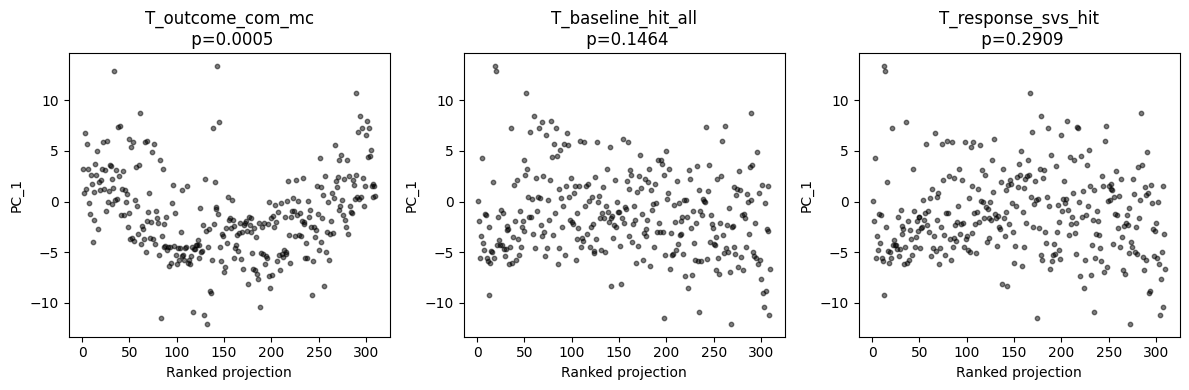

In [37]:
# project ccfs to cca axis and plot against features
fig, axes = plt.subplots(1, 3, figsize=(12,4), squeeze=False)
curr_focus_features = ['T_outcome_com_mc', 'T_baseline_hit_all', 'T_response_svs_hit']
for ind, feature in enumerate(['PC_1']):
    for ind_beh, beh_feature in enumerate(curr_focus_features):
        cca_1 = np.array(spatial_dependence_beh[beh_feature]['linear_trend']['coef_const_x_y_z'][1:])
        ax = axes[ind, ind_beh]
        values = cross_corr_df[feature].values
        projections = ccfs @ cca_1
        projections[~np.isnan(projections)] = rankdata(projections[~np.isnan(projections)])
        ax.scatter(projections, values, color='k', alpha=0.5, s=10)
        # fit linear regression
        ax.set_xlabel('Ranked projection')
        ax.set_ylabel(feature)
        ax.set_title(f'{beh_feature}\n p={correlation_results[(feature, beh_feature)]["cv_predictability_knn"]["p_value_permutation"]:.4f}')
plt.tight_layout()
save_panels(fig, target_folder, f'cross_corr_feature_vs_single_beh_spatial_axis_{criteria_name}', ['FigureE12t'], exts=('pdf',), dpi=300, bbox_inches='tight')
# ---- panel CSV (rule 1: scatter, feature values vs ranked projection on each beh axis) ----
_c = {}
for _bf in curr_focus_features:
    _cca = np.array(spatial_dependence_beh[_bf]['linear_trend']['coef_const_x_y_z'][1:])
    _proj = ccfs @ _cca
    _proj[~np.isnan(_proj)] = rankdata(_proj[~np.isnan(_proj)])
    _c[f'ranked_proj_{_bf}'] = _proj
for _f in focus_features:
    _c[f'value_{_f}'] = cross_corr_df[_f].values
df = columns_to_df(**_c)
behavior_cols = [f'ranked_proj_{_bf}' for _bf in curr_focus_features]
# Remove rows where all behavior columns are NaN
df = df.dropna(subset=behavior_cols, how='all')
save_panel_csv(
    df,
    target_folder,
    f'cross_corr_feature_vs_single_beh_spatial_axis_{criteria_name}',
    ['FigureE12t']
)
##FigureE12t##

## Project onto Waveform-PC Spatial Axes

Load the waveform-PCA spatial axes from `spatial_dependence_results_pca_waveform_all.pkl` and test whether cross-correlation PC1 varies along the gradients that define putative cell-type composition (waveform PC1/PC2) across recording sites.

In [38]:
focus_features = ['PC_1']

In [39]:
waveform_spatial = os.path.join(capsule_dirs["manuscript_fig_dir"], 'F_waveform_space', 'spatial_dependence_results_pca_waveform_all.pkl')
with open(waveform_spatial, 'rb') as f:
    spatial_dependence_waveform = pickle.load(f)

In [40]:
correlation_results_waveform = {}
for ind, feature in enumerate(focus_features):
    for _, wf_feature in enumerate(spatial_dependence_waveform.keys()):
        values = cross_corr_df[feature].values
        projections = ccfs @ spatial_dependence_waveform[wf_feature]['linear_trend']['coef_const_x_y_z'][1:4]
        results = spatial_dependence_summary(projections.T, values, k_neighbors=30, n_splits=5, permutations=2000, seed=42)
        correlation_results_waveform[(feature, wf_feature)] = results

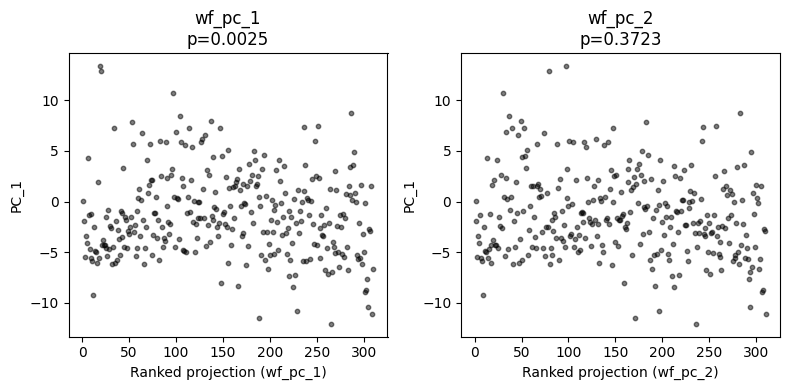

In [41]:
# plot PC_1 against projected location of cell along behavior primary axes
fig, axes = plt.subplots(1, 2, figsize=(8, 4), squeeze=False)
curr_focus_features = ['wf_pc_1', 'wf_pc_2']
for ind_beh, wf_feature in enumerate(curr_focus_features):
    wf_axis = np.array(spatial_dependence_waveform[wf_feature]['linear_trend']['coef_const_x_y_z'][1:])
    ax = axes[0, ind_beh]
    values = cross_corr_df['PC_1'].values
    projections = ccfs @ wf_axis
    projections[~np.isnan(projections)] = rankdata(projections[~np.isnan(projections)])
    ax.scatter(projections, values, color='k', alpha=0.5, s=10)
    ax.set_xlabel(f'Ranked projection ({wf_feature})')
    ax.set_ylabel('PC_1')
    ax.set_title(
        f'{wf_feature}\n'
        f'p={correlation_results_waveform[("PC_1", wf_feature)]["cv_predictability_knn"]["p_value_permutation"]:.4f}'
    )
plt.tight_layout()
save_panels(fig, target_folder, f'cross_corr_feature_vs_single_wf_spatial_axis_{criteria_name}', ['FigureE12t_topleft'], exts=('pdf',), dpi=300, bbox_inches='tight')
# ---- panel CSV (rule 1: scatter, PC_1 vs ranked projection on each waveform axis) ----
_c = {}
for _wf in curr_focus_features:
    _axis = np.array(spatial_dependence_waveform[_wf]['linear_trend']['coef_const_x_y_z'][1:])
    _proj = ccfs @ _axis
    _proj[~np.isnan(_proj)] = rankdata(_proj[~np.isnan(_proj)])
    _c[f'ranked_proj_{_wf}'] = _proj
_c['value_PC_1'] = cross_corr_df['PC_1'].values
df = columns_to_df(**_c)
wf_cols = [f'ranked_proj_{_wf}' for _wf in curr_focus_features]
df = df.dropna(subset=wf_cols, how='all')
save_panel_csv(
    df,
    target_folder,
    f'cross_corr_feature_vs_single_wf_spatial_axis_{criteria_name}',
    ['FigureE12t_topleft']
)
plt.show()
##FigureE12t_topleft##